Title: cluster_plt.ipynb

Purpose: Make a nice plot of the clusters

Author: Onno Nennecke on 15.06.2025 Modified: 21.10.2025

Input data: 

- centroids and labels
    - These files lie here: /home/onennecke/psl_clustering/clustering_results_nbc.npz'
    - These files lie here: /home/onennecke/psl_clustering/clustering_results_nbc_2.npz
- LEE Tables: LEE_dat_14.csv, LEE_dat_7.csv, LEE_dat.csv, LEE_dat_14_selection.csv, LEE_dat_7_selection.csv, LEE_vl.csv
    - This file lies here: '/climca/people/onennecke/model_output/LEE_detection/'
- PSL Data
    - This file lies here: /climca/people/onennecke/model_output/psl_anomaly/not_bc/

Output data:

- Cluster Plot: cluster_analysis_2x2, cluster_analysis_combined, cluster_analysis_combined_v2
    - This file lies here: /home/onennecke/Code/Figures/

In [1]:
# Load libraries
import os
import glob
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.gridspec import GridSpec
from matplotlib.cm import ScalarMappable
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from datetime import datetime, timedelta
from matplotlib.patches import Patch
import cftime


In [2]:
def setup_gridlines(ax, deg = 20, alpha = 0.4, ll = True, bl = True, label_size = 14):
    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), alpha=alpha)
    gl.top_labels = False
    gl.right_labels = False
    if not ll:
        gl.left_labels = False
    if not bl:
        gl.bottom_labels = False
    gl.xlabel_style = {'size': label_size}
    gl.ylabel_style = {'size': label_size}
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlocator = MultipleLocator(deg)
    gl.ylocator = MultipleLocator(deg)

In [3]:
def create_date_list(LEE_data, cluster_data):
    """
    For each row in LEE_data, take 'date_start' and 'date_end' strings (YYYY-MM-DD),
    compute all calendar dates in that interval (inclusive), wrapping across year-end
    if start > end, but explicitly skip any leap day (Feb 29).

    Parameters:
        LEE_data (pd.DataFrame): must contain 'date_start' and 'date_end' as YYYY-MM-DD.

    Returns:
        list[str]: flat list of dates (YYYY-MM-DD) covering each event, without Feb 29.
    """
    # date_list = []
    records = []
    for start_str, end_str, esm_run in zip(LEE_data['date_start'], LEE_data['date_end'], LEE_data['ESM_run']):
        start_date = datetime.strptime(start_str, "%Y-%m-%d").date()
        end_date   = datetime.strptime(end_str,   "%Y-%m-%d").date()
        num_days = (end_date - start_date).days + 1
        for offset in range(num_days):
            current = start_date + timedelta(days=offset)
            # current64 = np.datetime64(current)  # now datetime64[ns]
            if current.month == 2 and current.day == 29:
                continue
            current_cftime = cftime.DatetimeNoLeap(current.year, current.month, current.day)

            cluster = cluster_data.sel(time=current_cftime, ESM_run=esm_run).item()
            records.append({"Dates": current.strftime("%Y-%m-%d"), "ESM_run": esm_run, "Cluster": cluster})
    return pd.DataFrame(records)



### Read LEE data

In [90]:
# Read the LEE data
LEE_dat = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat.csv')

LEE_dat_7_all = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_7.csv')
LEE_7 = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_7_selection.csv')

LEE_dat_14_all = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_14.csv')
LEE_14 = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_14_selection.csv')

LEE_vl = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_vl.csv')


In [91]:
# Remove all SMARD and ERA5_wwd data from the LEE_dat DataFrame
LEE_dat = LEE_dat[(LEE_dat['ESM'] != 'SMARD') & (LEE_dat['ESM'] != 'ERA5_wwd')]
LEE_7 = LEE_7[(LEE_7['ESM'] != 'SMARD') & (LEE_7['ESM'] != 'ERA5_wwd')]
LEE_14 = LEE_14[(LEE_14['ESM'] != 'SMARD') & (LEE_14['ESM'] != 'ERA5_wwd')]
LEE_vl = LEE_vl[(LEE_vl['ESM'] != 'SMARD') & (LEE_vl['ESM'] != 'ERA5_wwd')]

# Rename ESM_run for ERA5_hist_week to ERA5_hist
LEE_dat['ESM_run'] = LEE_dat['ESM_run'].replace({'ERA5_hist_week': 'ERA5_hist'})
LEE_7['ESM_run'] = LEE_7['ESM_run'].replace({'ERA5_hist_week': 'ERA5_hist'})
LEE_14['ESM_run'] = LEE_14['ESM_run'].replace({'ERA5_hist_week': 'ERA5_hist'})
LEE_vl['ESM_run'] = LEE_vl['ESM_run'].replace({'ERA5_hist_week': 'ERA5_hist'})

# Remove all events that start or end outside of October-March
LEE_dat = LEE_dat[((LEE_dat['date_start'].str[5:7].isin(['01', '02', '03','10', '11', '12'])) & (LEE_dat['date_end'].str[5:7].isin(['01', '02', '03','10', '11', '12'])))]
LEE_7 = LEE_7[((LEE_7['date_start'].str[5:7].isin(['01', '02', '03','10', '11', '12'])) & (LEE_7['date_end'].str[5:7].isin(['01', '02', '03','10', '11', '12'])))]
LEE_14 = LEE_14[((LEE_14['date_start'].str[5:7].isin(['01', '02', '03','10', '11', '12'])) & (LEE_14['date_end'].str[5:7].isin(['01', '02', '03','10', '11', '12'])))]
LEE_vl = LEE_vl[((LEE_vl['date_start'].str[5:7].isin(['01', '02', '03','10', '11', '12'])) & (LEE_vl['date_end'].str[5:7].isin(['01', '02', '03','10', '11', '12'])))]

### Read PSL data

In [97]:
path = '/climca/people/onennecke/model_output/psl_anomaly/not_bc/'

files = sorted(glob.glob(os.path.join(path, '*.nc')))
ts_datasets = xr.open_mfdataset(files, combine='nested', concat_dim='ESM_run')

ts_datasets

<xarray.Dataset> Size: 3GB
Dimensions:    (ESM_run: 193, time: 1820, lat: 40, lon: 50)
Coordinates:
  * lat        (lat) int64 320B 30 31 32 33 34 35 36 37 ... 63 64 65 66 67 68 69
    crs        (time) int64 15kB dask.array<chunksize=(1820,), meta=np.ndarray>
    gridtype   (time) <U6 44kB dask.array<chunksize=(1820,), meta=np.ndarray>
  * lon        (lon) int64 400B 340 341 342 343 344 345 ... 24 25 26 27 28 29
  * time       (time) object 15kB 2015-01-01 00:00:00 ... 2024-12-31 00:00:00
    ESM        (time, ESM_run) <U13 18MB dask.array<chunksize=(1820, 3), meta=np.ndarray>
    run        (ESM_run, time) <U12 17MB dask.array<chunksize=(3, 1820), meta=np.ndarray>
  * ESM_run    (ESM_run) <U23 18kB 'ACCESS-CM2_r4i1p1f1' ... 'UKESM1-0-LL_r14...
    dayofyear  (time) int64 15kB dask.array<chunksize=(1820,), meta=np.ndarray>
Data variables:
    psl        (ESM_run, time, lat, lon) float32 3GB dask.array<chunksize=(3, 1820, 40, 50), meta=np.ndarray>

### Read cluster data

In [98]:
data = np.load('/home/onennecke/psl_clustering/old/clustering_results_nbc.npz')
labels = data['labels']
centroids_reshaped = data['centroids_reshaped']

In [99]:
# 1) Unpack sizes & coords
times   = ts_datasets.time           # (1820,)
runs    = ts_datasets.ESM_run        # (11,)
ESM    = ts_datasets.ESM            # (11,)
# print(times.shape, runs.shape)

# 2) Reshape labels → (time, ESM_run)
labels_da = xr.DataArray(
    labels.reshape(len(runs), len(times)),
    dims    = ("ESM_run", "time"),
    coords  = {"ESM_run": runs, "time": times, 'ESM': ESM},
    name    = "cluster_id",
)
labels_da

<xarray.DataArray 'cluster_id' (ESM_run: 193, time: 1820)> Size: 1MB
array([[1, 1, 1, ..., 4, 4, 4],
       [3, 3, 3, ..., 0, 0, 0],
       [0, 2, 3, ..., 2, 4, 4],
       ...,
       [1, 1, 1, ..., 3, 3, 2],
       [1, 1, 1, ..., 2, 2, 2],
       [3, 3, 2, ..., 1, 1, 1]], dtype=int32)
Coordinates:
  * ESM_run  (ESM_run) <U23 18kB 'ACCESS-CM2_r4i1p1f1' ... 'UKESM1-0-LL_r14i1...
  * time     (time) object 15kB 2015-01-01 00:00:00 ... 2024-12-31 00:00:00
    ESM      (time, ESM_run) <U13 18MB dask.array<chunksize=(1820, 3), meta=np.ndarray>

In [100]:
path = '/climca/people/onennecke/model_output/psl_anomaly/old/not_bc_old/'

files = sorted(glob.glob(os.path.join(path, '*.nc')))
ts_datasets = xr.open_mfdataset(files, combine='nested', concat_dim='ESM_run')

ts_datasets

<xarray.Dataset> Size: 1GB
Dimensions:        (ESM_run: 100, time: 1820, lat: 40, lon: 50)
Coordinates:
  * time           (time) datetime64[ns] 15kB 2015-01-01T12:00:00 ... 2024-12...
  * lat            (lat) int64 320B 30 31 32 33 34 35 36 ... 64 65 66 67 68 69
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
  * lon            (lon) int64 400B 340 341 342 343 344 345 ... 25 26 27 28 29
    ESM            (ESM_run) <U13 5kB 'ACCESS-CM2' ... 'UKESM1-0-LL'
    run            (ESM_run) <U10 4kB 'r1i1p1f1' 'r4i1p1f1' ... 'r9i1p1f2'
  * ESM_run        (ESM_run) <U23 9kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0-LL_...
    winter_year    (time) int64 15kB dask.array<chunksize=(1820,), meta=np.ndarray>
    day_of_winter  (time) int64 15kB dask.array<chunksize=(1820,), meta=np.ndarray>
    winter_season  (time) <U8 58kB dask.array<chunksize=(1820,), meta=np.ndarray>
    old_time       (ESM_run, time) object 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>
Data variables:
    psl            (ESM_run, time, lat, lon) float32 1GB dask.array<chunksize=(1, 1820, 40, 50), meta=np.ndarray>
Attributes:
    regrid_method:  bilinear

In [101]:
data = np.load('/home/onennecke/psl_clustering/old/very_old/clustering_results_nbc.npz')
labels = data['labels']
centroids_reshaped = data['centroids_reshaped']
labels

array([4, 4, 4, ..., 1, 1, 1], dtype=int32)

In [160]:
# 1) Unpack sizes & coords
times   = ts_datasets.time           # (1820,)
runs    = ts_datasets.ESM_run        # (11,)
ESM    = ts_datasets.ESM            # (11,)
# print(times.shape, runs.shape)

# 2) Reshape labels → (time, ESM_run)
labels_da_old = xr.DataArray(
    labels.reshape(len(runs), len(times)),
    dims    = ("ESM_run", "time"),
    coords  = {"ESM_run": runs, "time": times, 'ESM': ESM},
    name    = "cluster_id",
)
labels_da_old

<xarray.DataArray 'cluster_id' (ESM_run: 100, time: 1820)> Size: 728kB
array([[4, 4, 4, ..., 3, 3, 3],
       [1, 1, 1, ..., 2, 2, 2],
       [2, 0, 0, ..., 0, 3, 3],
       ...,
       [4, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 4, 4, 4],
       [2, 3, 3, ..., 1, 1, 1]], dtype=int32)
Coordinates:
  * ESM_run  (ESM_run) <U23 9kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0-LL_r9i1p1f2'
  * time     (time) datetime64[ns] 15kB 2015-01-01T12:00:00 ... 2024-12-31T12...
    ESM      (ESM_run) <U13 5kB 'ACCESS-CM2' 'ACCESS-CM2' ... 'UKESM1-0-LL'

In [161]:
common_runs = sorted(set(labels_da_old['ESM_run'].values).intersection(labels_da['ESM_run'].values))

labels_da_old = labels_da_old.sel(ESM_run=common_runs)
labels_da     = labels_da.sel(ESM_run=common_runs)

print(len(common_runs), "common ESM_run values")

92 common ESM_run values


In [147]:
labels_da.sel(ESM_run = "ACCESS-CM2_r5i1p1f1", time = slice("2024-10-01", "2024-12-15"))

<xarray.DataArray 'cluster_id' (time: 76)> Size: 304B
array([3, 3, 3, 3, 3, 0, 2, 2, 4, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 4, 4,
       4, 3, 3, 4, 4, 4, 4, 4, 2, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 0, 0, 0, 0, 0, 2, 3, 3, 3, 3, 3, 3, 1, 1, 3,
       1, 3, 3, 3, 2, 2, 1, 1, 3, 3], dtype=int32)
Coordinates:
    ESM_run  <U23 92B 'ACCESS-CM2_r5i1p1f1'
  * time     (time) object 608B 2024-10-01 00:00:00 ... 2024-12-15 00:00:00
    ESM      (time) <U13 4kB dask.array<chunksize=(76,), meta=np.ndarray>

In [148]:
labels_da_old.sel(ESM_run = "ACCESS-CM2_r5i1p1f1", time = slice("2024-10-01", "2024-12-15"))

<xarray.DataArray 'cluster_id' (time: 76)> Size: 304B
array([3, 4, 1, 1, 0, 0, 0, 0, 4, 0, 0, 0, 4, 4, 4, 4, 0, 0, 4, 0, 3, 3,
       2, 3, 0, 0, 1, 3, 2, 2, 2, 0, 0, 4, 4, 4, 4, 4, 4, 4, 4, 1, 1, 1,
       1, 1, 1, 0, 0, 0, 3, 0, 0, 0, 0, 0, 4, 4, 1, 1, 1, 1, 2, 2, 1, 1,
       1, 1, 1, 1, 1, 0, 0, 0, 0, 0], dtype=int32)
Coordinates:
    ESM_run  <U23 92B 'ACCESS-CM2_r5i1p1f1'
    ESM      <U13 52B 'ACCESS-CM2'
  * time     (time) object 608B 2024-10-01 00:00:00 ... 2024-12-15 00:00:00

In [162]:
mapping = {0: 2, 4: 1, 2: 0, 1: 3, 3: 4}
# mapping = {0: 0, 4: 1, 2: 2, 3: 3, 1: 4}

labels_da_old = xr.apply_ufunc(np.vectorize(mapping.get), labels_da_old)
labels_da_old = labels_da_old.assign_coords(time=labels_da['time'].values)

In [145]:
labels_da_old = labels_da_old.assign_coords(time=labels_da['time'].values)

In [136]:
labels_da.time

<xarray.DataArray 'time' (time: 1820)> Size: 15kB
array([cftime.DatetimeNoLeap(2015, 1, 1, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2015, 1, 2, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2015, 1, 3, 0, 0, 0, 0, has_year_zero=True), ...,
       cftime.DatetimeNoLeap(2024, 12, 29, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2024, 12, 30, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2024, 12, 31, 0, 0, 0, 0, has_year_zero=True)],
      dtype=object)
Coordinates:
  * time     (time) object 15kB 2015-01-01 00:00:00 ... 2024-12-31 00:00:00

In [141]:
labels_da_old

<xarray.DataArray 'cluster_id' (ESM_run: 92, time: 1820)> Size: 1MB
array([[1, 1, 1, ..., 4, 4, 4],
       [3, 3, 3, ..., 0, 0, 0],
       [0, 2, 2, ..., 2, 4, 4],
       ...,
       [1, 1, 1, ..., 2, 2, 2],
       [1, 2, 2, ..., 2, 2, 2],
       [2, 2, 2, ..., 1, 1, 1]])
Coordinates:
  * ESM_run  (ESM_run) <U23 8kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0-LL_r8i1p1f2'
    ESM      (ESM_run) <U13 5kB 'ACCESS-CM2' 'ACCESS-CM2' ... 'UKESM1-0-LL'
  * time     (time) object 15kB 2015-01-01 00:00:00 ... 2024-12-31 00:00:00

ESM_run
EC-Earth3_r113i1p1f1      0.180769
EC-Earth3_r146i1p1f1      0.183516
MRI-ESM2-0_r1i1p1f1       0.184066
CESM2_r10i1p1f1           0.185714
UKESM1-0-LL_r15i1p1f2     0.187363
                            ...   
ERA5_hist                 0.944505
MPI-ESM1-2-HR_r7i1p1f1    0.958242
BCC-CSM2-MR_r1i1p1f1      0.958791
GFDL-ESM4_r1i1p1f1        0.965934
TaiESM1_r1i1p1f1          0.967582
Name: cluster_id, Length: 92, dtype: float64


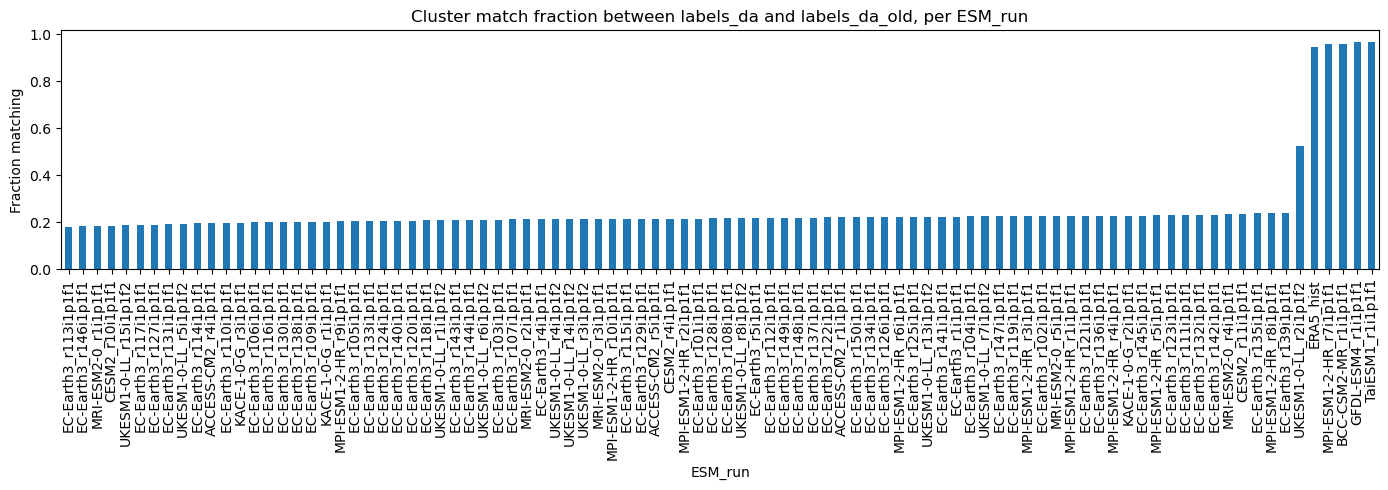

In [163]:
match_per_run = (labels_da == labels_da_old).sum(dim='time') / labels_da.sizes['time']
match_per_run = match_per_run.to_series().sort_values()

print(match_per_run)

match_per_run.plot(kind='bar', figsize=(14, 5))
plt.ylabel('Fraction matching')
plt.xlabel('ESM_run')
plt.title('Cluster match fraction between labels_da and labels_da_old, per ESM_run')
plt.tight_layout()
plt.show()

In [139]:
match_count = (labels_da == labels_da_old).sum().item()
total = labels_da.size
print(f"{match_count} / {total} entries match ({match_count/total:.2%})")

43229 / 167440 entries match (25.82%)


In [130]:
old_counts = labels_da_old.to_series().value_counts()
new_counts = labels_da.to_series().value_counts()
print("Old counts:\n", old_counts)
print("\nNew counts:\n", new_counts)

Old counts:
 cluster_id
3    38095
1    37613
4    31517
2    30793
0    29422
Name: count, dtype: int64

New counts:
 cluster_id
3    39599
1    36584
4    31555
2    30505
0    29197
Name: count, dtype: int64


In [55]:
labels
len(labels)
# Count how many times each cluster appears
unique, counts = np.unique(labels, return_counts=True)
unique, counts

(array([0, 1, 2, 3, 4], dtype=int32),
 array([33610, 41529, 31781, 34370, 40710]))

In [89]:
LEE_dat_old = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/MA_old_model/LEE_dat.csv')
LEE_dat_old

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
0,2015-01-05,2015-01-05,2015-01-05,4,4,4,1,1423.036821,1423.036821,0.0,1423.036821,1,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,5
1,2015-01-07,2015-01-07,2015-01-07,6,6,6,1,1437.904166,1437.904166,0.0,1437.904166,2,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,7
2,2015-01-08,2015-01-08,2015-01-08,7,7,7,1,1479.128472,1479.128472,0.0,1479.128472,3,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,8
3,2015-01-18,2015-01-18,2015-01-18,17,17,17,1,1469.444224,1469.444224,0.0,1469.444224,4,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,18
4,2015-01-19,2015-01-19,2015-01-19,18,18,18,1,1484.203439,1484.203439,0.0,1484.203439,5,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18600,2022-01-25,2022-01-25,2022-01-25,2579,2579,2579,1,1433.217750,1433.217750,0.0,1433.217750,18601,SMARD,SMARD_hist,2022,25
18601,2023-11-30,2023-11-30,2023-11-30,3253,3253,3253,1,1446.194500,1446.194500,0.0,1446.194500,18602,SMARD,SMARD_hist,2023,334
18602,2023-12-01,2023-12-01,2023-12-01,3254,3254,3254,1,1409.966000,1409.966000,0.0,1409.966000,18603,SMARD,SMARD_hist,2023,335
18603,2024-12-11,2024-12-11,2024-12-11,3629,3629,3629,1,1425.075500,1425.075500,0.0,1425.075500,18604,SMARD,SMARD_hist,2024,345


In [93]:
common_runs = set(LEE_dat_old['ESM_run']).intersection(LEE_dat['ESM_run'])

LEE_dat_old = LEE_dat_old[LEE_dat_old['ESM_run'].isin(common_runs)].reset_index(drop=True)
LEE_dat     = LEE_dat[LEE_dat['ESM_run'].isin(common_runs)].reset_index(drop=True)

# print(len(common_runs), "common ESM_run values")

In [94]:
LEE_dat_old

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
0,2015-01-05,2015-01-05,2015-01-05,4,4,4,1,1423.036821,1423.036821,0.0,1423.036821,1,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,5
1,2015-01-07,2015-01-07,2015-01-07,6,6,6,1,1437.904166,1437.904166,0.0,1437.904166,2,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,7
2,2015-01-08,2015-01-08,2015-01-08,7,7,7,1,1479.128472,1479.128472,0.0,1479.128472,3,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,8
3,2015-01-18,2015-01-18,2015-01-18,17,17,17,1,1469.444224,1469.444224,0.0,1469.444224,4,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,18
4,2015-01-19,2015-01-19,2015-01-19,18,18,18,1,1484.203439,1484.203439,0.0,1484.203439,5,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16004,2024-12-24,2024-12-24,2024-12-24,3642,3642,3642,1,1399.907401,1399.907401,0.0,1399.907401,18258,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2024,358
16005,2024-12-25,2024-12-25,2024-12-25,3643,3643,3643,1,1459.284803,1459.284803,0.0,1459.284803,18259,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2024,359
16006,2024-12-29,2024-12-29,2024-12-29,3647,3647,3647,1,1411.477467,1411.477467,0.0,1411.477467,18260,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2024,363
16007,2024-12-30,2024-12-30,2024-12-30,3648,3648,3648,1,1578.011744,1578.011744,0.0,1578.011744,18261,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2024,364


In [95]:
LEE_dat

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
0,2015-01-05,2015-01-05,2015-01-05,4,4,4,1,1347.755832,1347.755832,0.0,1347.755832,1,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,5
1,2015-01-07,2015-01-07,2015-01-07,6,6,6,1,1333.134503,1333.134503,0.0,1333.134503,2,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,7
2,2015-01-08,2015-01-08,2015-01-08,7,7,7,1,1395.107358,1395.107358,0.0,1395.107358,3,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,8
3,2015-01-18,2015-01-18,2015-01-18,17,17,17,1,1409.547842,1409.547842,0.0,1409.547842,4,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,18
4,2015-01-19,2015-01-19,2015-01-19,18,18,18,1,1403.974418,1403.974418,0.0,1403.974418,5,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14099,2024-12-20,2024-12-20,2024-12-20,3638,3638,3638,1,1455.111286,1455.111286,0.0,1455.111286,35219,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2024,354
14100,2024-12-21,2024-12-21,2024-12-21,3639,3639,3639,1,1433.341128,1433.341128,0.0,1433.341128,35220,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2024,355
14101,2024-12-25,2024-12-25,2024-12-25,3643,3643,3643,1,1392.939718,1392.939718,0.0,1392.939718,35221,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2024,359
14102,2024-12-30,2024-12-30,2024-12-30,3648,3648,3648,1,1506.619573,1506.619573,0.0,1506.619573,35222,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2024,364


In [96]:
old_keys = set(zip(LEE_dat_old['date_start'], LEE_dat_old['ESM_run']))
new_keys = set(zip(LEE_dat['date_start'], LEE_dat['ESM_run']))

shared_keys = old_keys & new_keys
print(f"{len(shared_keys)} (date_start, ESM_run) combinations appear in both datasets")

13768 (date_start, ESM_run) combinations appear in both datasets


In [12]:
LEE_dat = LEE_dat[(LEE_dat['ESM'] != 'CESM2')]

LEE_dat


,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
0,2015-01-05,2015-01-05,2015-01-05,4,4,4,1,1347.755832,1347.755832,0.0,1347.755832,1,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,5
1,2015-01-07,2015-01-07,2015-01-07,6,6,6,1,1333.134503,1333.134503,0.0,1333.134503,2,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,7
2,2015-01-08,2015-01-08,2015-01-08,7,7,7,1,1395.107358,1395.107358,0.0,1395.107358,3,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,8
3,2015-01-18,2015-01-18,2015-01-18,17,17,17,1,1409.547842,1409.547842,0.0,1409.547842,4,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,18
4,2015-01-19,2015-01-19,2015-01-19,18,18,18,1,1403.974418,1403.974418,0.0,1403.974418,5,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35218,2024-12-20,2024-12-20,2024-12-20,3638,3638,3638,1,1455.111286,1455.111286,0.0,1455.111286,35219,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2024,354
35219,2024-12-21,2024-12-21,2024-12-21,3639,3639,3639,1,1433.341128,1433.341128,0.0,1433.341128,35220,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2024,355
35220,2024-12-25,2024-12-25,2024-12-25,3643,3643,3643,1,1392.939718,1392.939718,0.0,1392.939718,35221,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2024,359
35221,2024-12-30,2024-12-30,2024-12-30,3648,3648,3648,1,1506.619573,1506.619573,0.0,1506.619573,35222,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2024,364


In [59]:
# LEE_dat_old = LEE_dat_old[(LEE_dat_old['ESM'] != 'CESM2') & (LEE_dat_old['ESM_run'] != 'UKESM1-0-LL_r10i1p1f2') & (LEE_dat_old['ESM'] != 'UKESM1-0-LL')]

# Remove all SMARD and ERA5_wwd data from the LEE_dat DataFrame
LEE_dat_old = LEE_dat_old[(LEE_dat_old['ESM'] != 'SMARD') & (LEE_dat_old['ESM'] != 'ERA5_wwd')]

# Rename ESM_run for ERA5_hist_week to ERA5_hist
LEE_dat_old['ESM_run'] = LEE_dat_old['ESM_run'].replace({'ERA5_hist_week': 'ERA5_hist'})

# Remove all events that start or end outside of October-March
LEE_dat_old = LEE_dat_old[((LEE_dat_old['date_start'].str[5:7].isin(['01', '02', '03','10', '11', '12'])) & (LEE_dat_old['date_end'].str[5:7].isin(['01', '02', '03','10', '11', '12'])))]


LEE_dat_old

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
0,2015-01-05,2015-01-05,2015-01-05,4,4,4,1,1423.036821,1423.036821,0.0,1423.036821,1,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,5
1,2015-01-07,2015-01-07,2015-01-07,6,6,6,1,1437.904166,1437.904166,0.0,1437.904166,2,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,7
2,2015-01-08,2015-01-08,2015-01-08,7,7,7,1,1479.128472,1479.128472,0.0,1479.128472,3,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,8
3,2015-01-18,2015-01-18,2015-01-18,17,17,17,1,1469.444224,1469.444224,0.0,1469.444224,4,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,18
4,2015-01-19,2015-01-19,2015-01-19,18,18,18,1,1484.203439,1484.203439,0.0,1484.203439,5,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18509,2024-11-11,2024-11-11,2024-11-11,3599,3599,3599,1,1421.402262,1421.402262,0.0,1421.402262,18510,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2024,315
18510,2024-11-14,2024-11-14,2024-11-14,3602,3602,3602,1,1412.689224,1412.689224,0.0,1412.689224,18511,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2024,318
18511,2024-11-16,2024-11-16,2024-11-16,3604,3604,3604,1,1468.658163,1468.658163,0.0,1468.658163,18512,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2024,320
18512,2024-12-20,2024-12-20,2024-12-20,3638,3638,3638,1,1470.535544,1470.535544,0.0,1470.535544,18513,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2024,354


In [16]:
# Count how many date_start/ESM_run combinations are the same for LEE_dat and LEE_dat_old
same_combinations = pd.merge(LEE_dat[['date_start', 'ESM_run']], LEE_dat_old[['date_start', 'ESM_run']], on=['date_start', 'ESM_run'], how='inner')
print(same_combinations.shape[0])

same_combinations_other_way = pd.merge(LEE_dat_old[['date_start', 'ESM_run']], LEE_dat[['date_start', 'ESM_run']], on=['date_start', 'ESM_run'], how='inner')
print(same_combinations_other_way.shape[0])

13528
13528


In [129]:
# Very old stuff!!!
# /climca/people/onennecke/model_output/LEE_detection/
path = '/climca/people/onennecke/model_output/psl_anomaly/old/not_bc_old'

files = sorted(glob.glob(os.path.join(path, '*.nc')))
ts_datasets = xr.open_mfdataset(files, combine='nested', concat_dim='ESM_run')

ts_datasets

data = np.load('/home/onennecke/psl_clustering/old/very_old/clustering_results_nbc.npz')
labels = data['labels']
centroids_reshaped = data['centroids_reshaped']
# 1) Unpack sizes & coords
times   = ts_datasets.time           # (1820,)
runs    = ts_datasets.ESM_run        # (11,)
ESM    = ts_datasets.ESM            # (11,)
# print(times.shape, runs.shape)

# 2) Reshape labels → (time, ESM_run)
labels_da = xr.DataArray(
    labels.reshape(len(runs), len(times)),
    dims    = ("ESM_run", "time"),
    coords  = {"ESM_run": runs, "time": times, 'ESM': ESM},
    name    = "cluster_id",
)
labels_da
# Read the LEE data
LEE_dat = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/MA_old_model/LEE_dat.csv')

LEE_dat_7_all = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/MA_old_model/LEE_dat_7.csv')
LEE_7 = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/MA_old_model/LEE_dat_7_selection.csv')

LEE_dat_14_all = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/MA_old_model/LEE_dat_14.csv')
LEE_14 = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/MA_old_model/LEE_dat_14_selection.csv')

LEE_vl = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/MA_old_model/LEE_vl.csv')
# Remove all SMARD and ERA5_wwd data from the LEE_dat DataFrame
LEE_dat = LEE_dat[(LEE_dat['ESM'] != 'SMARD') & (LEE_dat['ESM'] != 'ERA5_wwd')]
LEE_7 = LEE_7[(LEE_7['ESM'] != 'SMARD') & (LEE_7['ESM'] != 'ERA5_wwd')]
LEE_14 = LEE_14[(LEE_14['ESM'] != 'SMARD') & (LEE_14['ESM'] != 'ERA5_wwd')]
LEE_vl = LEE_vl[(LEE_vl['ESM'] != 'SMARD') & (LEE_vl['ESM'] != 'ERA5_wwd')]

# Rename ESM_run for ERA5_hist_week to ERA5_hist
LEE_dat['ESM_run'] = LEE_dat['ESM_run'].replace({'ERA5_hist_week': 'ERA5_hist'})
LEE_7['ESM_run'] = LEE_7['ESM_run'].replace({'ERA5_hist_week': 'ERA5_hist'})
LEE_14['ESM_run'] = LEE_14['ESM_run'].replace({'ERA5_hist_week': 'ERA5_hist'})
LEE_vl['ESM_run'] = LEE_vl['ESM_run'].replace({'ERA5_hist_week': 'ERA5_hist'})

# Remove all events that start or end outside of October-March
LEE_dat = LEE_dat[((LEE_dat['date_start'].str[5:7].isin(['01', '02', '03','10', '11', '12'])) & (LEE_dat['date_end'].str[5:7].isin(['01', '02', '03','10', '11', '12'])))]
LEE_7 = LEE_7[((LEE_7['date_start'].str[5:7].isin(['01', '02', '03','10', '11', '12'])) & (LEE_7['date_end'].str[5:7].isin(['01', '02', '03','10', '11', '12'])))]
LEE_14 = LEE_14[((LEE_14['date_start'].str[5:7].isin(['01', '02', '03','10', '11', '12'])) & (LEE_14['date_end'].str[5:7].isin(['01', '02', '03','10', '11', '12'])))]
LEE_vl = LEE_vl[((LEE_vl['date_start'].str[5:7].isin(['01', '02', '03','10', '11', '12'])) & (LEE_vl['date_end'].str[5:7].isin(['01', '02', '03','10', '11', '12'])))]




In [38]:
# Change all esm_run values that contain _LE_LE2_ to _LE2_
labels_da = labels_da.assign_coords(ESM_run=labels_da.ESM_run.str.replace('_LE_LE2', '_LE2'))

In [10]:
ts_datasets

<xarray.Dataset> Size: 3GB
Dimensions:    (ESM_run: 193, time: 1820, lat: 40, lon: 50)
Coordinates:
  * lat        (lat) int64 320B 30 31 32 33 34 35 36 37 ... 63 64 65 66 67 68 69
    crs        (time) int64 15kB dask.array<chunksize=(1820,), meta=np.ndarray>
    gridtype   (time) <U6 44kB dask.array<chunksize=(1820,), meta=np.ndarray>
  * lon        (lon) int64 400B 340 341 342 343 344 345 ... 24 25 26 27 28 29
  * time       (time) object 15kB 2015-01-01 00:00:00 ... 2024-12-31 00:00:00
    ESM        (time, ESM_run) <U13 18MB dask.array<chunksize=(1820, 3), meta=np.ndarray>
    run        (ESM_run, time) <U12 17MB dask.array<chunksize=(3, 1820), meta=np.ndarray>
  * ESM_run    (ESM_run) <U23 18kB 'ACCESS-CM2_r4i1p1f1' ... 'UKESM1-0-LL_r14...
    dayofyear  (time) int64 15kB dask.array<chunksize=(1820,), meta=np.ndarray>
Data variables:
    psl        (ESM_run, time, lat, lon) float32 3GB dask.array<chunksize=(3, 1820, 40, 50), meta=np.ndarray>

In [17]:
# ────────────── 1) Recover time‐coordinates for each “flattened” sample ──────────────
n_ESM = ts_datasets.sizes['ESM_run']  # number of ESM runs
n_times = ts_datasets.sizes['time']    # number of time‐slices
time_coords = ts_datasets['time'].values      # shape = (n_times,), dtype=datetime64
# ESM = ts_datasets['ESM'].values

times_repeated = np.repeat(time_coords, n_ESM)

len(times_repeated)

# ────────────── 2) Recover ESM‐run coordinates for each “flattened” sample ──────────────
ESM_run = ts_datasets['ESM_run'].values
esm_run_coords = np.repeat(ESM_run, n_times)
esm_run_coords

# ────────────── 3) Build a small DataFrame with (time, cluster) ──────────────

df = pd.DataFrame({
    "time":    times_repeated,
    "cluster": labels,
    "ESM_run": esm_run_coords,
    # "ESM": np.repeat(ESM, n_times)
})

# ────────────── 4) Map each date → its meteorological season ──────────────

def month_to_season(m):
    # Meteorological seasons in the northern hemisphere:
    if m in (12, 1, 2):
        return "DJF"
    elif m in (3, 4, 5):
        return "MAM"
    elif m in (6, 7, 8):
        return "JJA"
    else:  # 9,10,11
        return "SON"

# Extract month from each timestamp, then map to season:
# df["month"]  = pd.DatetimeIndex(df["time"]).month
df["month"] = [t.month for t in df["time"]]
df["season"] = df["month"].map(month_to_season)

df["year"] = [t.year for t in df["time"]]
df["doy"] = [t.timetuple().tm_yday for t in df["time"]]
# ────────────── 5) Count how many samples of each cluster fall in each Month ──────────────

# This gives you a table with index = cluster ID, columns = month, and counts = number of samples.
monthly_counts = (
    df
    .groupby(["cluster", "month"])
    .size()
    .unstack(fill_value=0)
)

# If you want fractions instead of raw counts, you can do:
monthly_frac = monthly_counts.div(monthly_counts.sum(axis=0), axis=1)

# ────────────── 6) Count how many samples of each cluster fall in each year ──────────────
yearly_counts = (
    df
    .groupby(["cluster", "year"])
    .size()
    .unstack(fill_value=0)
)
# If you want fractions instead of raw counts, you can do:
yearly_frac = yearly_counts.div(yearly_counts.sum(axis=0), axis=1)

# ────────────── 7) Count how many samples of each cluster fall in each doy ──────────────
doy_counts = (
    df
    .groupby(["cluster", "doy"])
    .size()
    .unstack(fill_value=0)
)
# If you want fractions instead of raw counts, you can do:
doy_frac = doy_counts.div(doy_counts.sum(axis=0), axis=1)

# ────────────── 7) Count samples of each cluster overall ──────────────
cluster_counts = df['cluster'].value_counts()


In [ ]:
cluster_counts

### Only cluster center maps

/tmp/ipykernel_2303763/4106348975.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


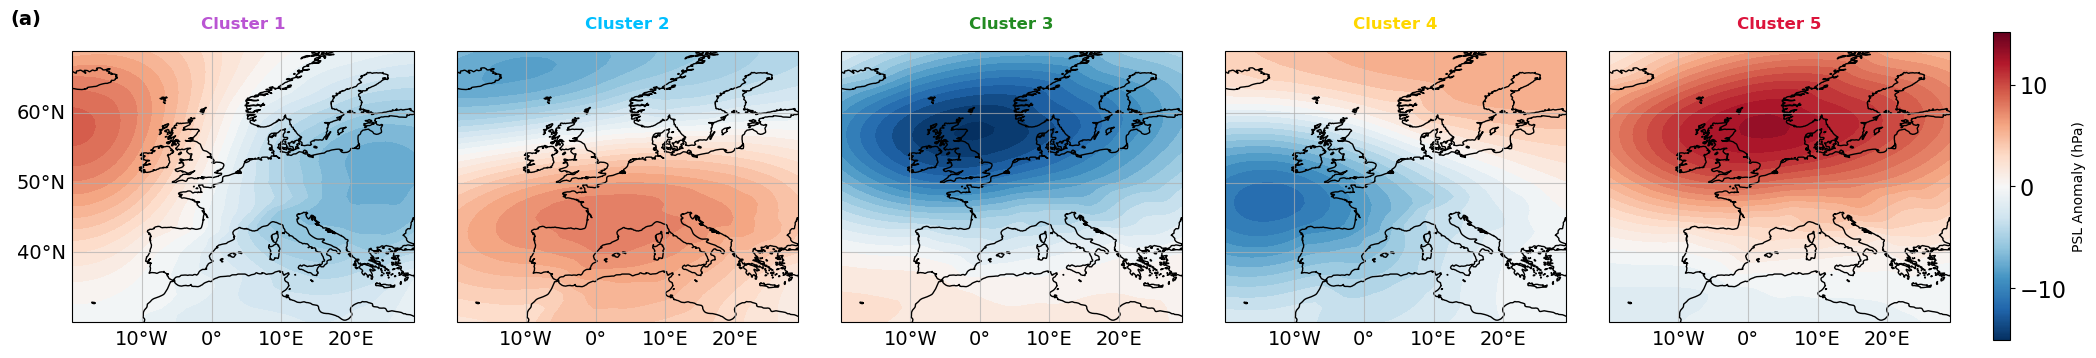

In [131]:
# Define cluster title colors (match figure)
cluster_colors = ["mediumorchid", "deepskyblue", "forestgreen", "gold", "crimson"]

# 1) Compute the global vmin/vmax over all clusters (in hPa)
vmin = np.nanmin(centroids_reshaped / 100.0)
vmax = -vmin # np.nanmax(centroids_reshaped / 100.0)

# 2) Decide on subplot grid
ncols = 5
nrows = 1

# 3) Create figure + GridSpec (extra col for colorbar)
fig = plt.figure(figsize=(5 * ncols, 4))
gs = GridSpec(nrows, ncols + 1, width_ratios=[1]*ncols + [0.05], wspace=0.15)

lons = ((ts_datasets['lon'].values + 180) % 360) - 180
lats = ts_datasets['lat'].values

for i in range(5):
    ax = fig.add_subplot(gs[0, i], projection=ccrs.PlateCarree())

    # Plot with red-blue color scheme
    cf = ax.contourf(
        lons, lats, (centroids_reshaped[i, :, :] / 100.0),
        levels=20, vmin=vmin, vmax=vmax,
        cmap="RdBu_r", transform=ccrs.PlateCarree()
    )
    cmap_used = cf.cmap

    ax.coastlines()
    if i == 0:
        setup_gridlines(ax, deg=10, alpha=0.7)
    else:
        setup_gridlines(ax, deg=10, alpha=0.7, ll=False)

    ax.set_title(f"Cluster {i + 1}", fontsize=12, color=cluster_colors[i], fontweight='bold')

# 4) Add (a) label
fig.text(0.1, 0.9, "(a)", fontsize=14, fontweight='bold')

# 5) Create ScalarMappable for colorbar
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = ScalarMappable(norm=norm, cmap=cmap_used)
sm.set_array([])

# 6) Add vertical colorbar on the right
cax = fig.add_subplot(gs[0, -1])
cbar = plt.colorbar(sm, cax=cax)
cbar.set_label('PSL Anomaly (hPa)', fontsize=10)

plt.tight_layout()
plt.show()

### Calculate dates from events

In [89]:
LEE_dat_dl

,Dates,ESM_run,Cluster
0,2015-01-05,ACCESS-CM2_r1i1p1f1,1
1,2015-01-07,ACCESS-CM2_r1i1p1f1,1
2,2015-01-08,ACCESS-CM2_r1i1p1f1,3
3,2015-01-18,ACCESS-CM2_r1i1p1f1,0
4,2015-01-19,ACCESS-CM2_r1i1p1f1,0
...,...,...,...
35212,2024-12-20,UKESM1-0-LL_r8i1p1f2,1
35213,2024-12-21,UKESM1-0-LL_r8i1p1f2,1
35214,2024-12-25,UKESM1-0-LL_r8i1p1f2,4
35215,2024-12-30,UKESM1-0-LL_r8i1p1f2,3


In [100]:
LEE_dat_dl['ESM_run'].unique()

array(['ACCESS-CM2_r1i1p1f1', 'ACCESS-CM2_r4i1p1f1',
       'ACCESS-CM2_r5i1p1f1', 'BCC-CSM2-MR_r1i1p1f1',
       'CESM2_LE2-1001_001', 'CESM2_LE2-1011_001', 'CESM2_LE2-1021_002',
       'CESM2_LE2-1031_002', 'CESM2_LE2-1041_003', 'CESM2_LE2-1051_003',
       'CESM2_LE2-1061_004', 'CESM2_LE2-1071_004', 'CESM2_LE2-1081_005',
       'CESM2_LE2-1091_005', 'CESM2_LE2-1101_006', 'CESM2_LE2-1111_006',
       'CESM2_LE2-1121_007', 'CESM2_LE2-1131_007', 'CESM2_LE2-1141_008',
       'CESM2_LE2-1151_008', 'CESM2_LE2-1161_009', 'CESM2_LE2-1171_009',
       'CESM2_LE2-1181_010', 'CESM2_LE2-1191_010', 'CESM2_LE2-1231_001',
       'CESM2_LE2-1231_002', 'CESM2_LE2-1231_003', 'CESM2_LE2-1231_004',
       'CESM2_LE2-1231_005', 'CESM2_LE2-1231_006', 'CESM2_LE2-1231_007',
       'CESM2_LE2-1231_008', 'CESM2_LE2-1231_009', 'CESM2_LE2-1231_010',
       'CESM2_LE2-1231_011', 'CESM2_LE2-1231_012', 'CESM2_LE2-1231_013',
       'CESM2_LE2-1231_014', 'CESM2_LE2-1231_015', 'CESM2_LE2-1231_016',
       'CESM2_LE2

In [114]:
LEE_dat_dl

# Only show ERA5_hist data dont show Nans
tst = LEE_dat_dl.where((LEE_dat_dl['ESM_run'] == "ERA5_hist"))
tst
# Drop all rows with NaN values in the 'Cluster' column
tst = tst.dropna(subset=['Cluster'])
tst['Cluster'].value_counts()

Cluster
1.0    67
2.0    37
4.0    34
3.0    20
0.0     2
Name: count, dtype: int64

In [101]:
LEE_dat_dl.where((LEE_dat_dl['ESM_run'] == "ERA5_hist"))

,Dates,ESM_run,Cluster
0,NaN,NaN,NaN
1,NaN,NaN,NaN
2,NaN,NaN,NaN
3,NaN,NaN,NaN
4,NaN,NaN,NaN
...,...,...,...
35212,NaN,NaN,NaN
35213,NaN,NaN,NaN
35214,NaN,NaN,NaN
35215,NaN,NaN,NaN


In [84]:
labels_da.sel(ESM_run = "ERA5_hist", time = slice("2024-10-29", "2024-11-15"))

<xarray.DataArray 'cluster_id' (time: 18)> Size: 72B
array([1, 1, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3], dtype=int32)
Coordinates:
  * time     (time) object 144B 2024-10-29 00:00:00 ... 2024-11-15 00:00:00
    ESM      (time) <U13 936B dask.array<chunksize=(18,), meta=np.ndarray>
    ESM_run  <U23 92B 'ERA5_hist'

In [120]:
LEE_dat

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
0,2015-01-05,2015-01-05,2015-01-05,4,4,4,1,1347.755832,1347.755832,0.0,1347.755832,1,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,5
1,2015-01-07,2015-01-07,2015-01-07,6,6,6,1,1333.134503,1333.134503,0.0,1333.134503,2,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,7
2,2015-01-08,2015-01-08,2015-01-08,7,7,7,1,1395.107358,1395.107358,0.0,1395.107358,3,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,8
3,2015-01-18,2015-01-18,2015-01-18,17,17,17,1,1409.547842,1409.547842,0.0,1409.547842,4,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,18
4,2015-01-19,2015-01-19,2015-01-19,18,18,18,1,1403.974418,1403.974418,0.0,1403.974418,5,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35218,2024-12-20,2024-12-20,2024-12-20,3638,3638,3638,1,1455.111286,1455.111286,0.0,1455.111286,35219,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2024,354
35219,2024-12-21,2024-12-21,2024-12-21,3639,3639,3639,1,1433.341128,1433.341128,0.0,1433.341128,35220,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2024,355
35220,2024-12-25,2024-12-25,2024-12-25,3643,3643,3643,1,1392.939718,1392.939718,0.0,1392.939718,35221,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2024,359
35221,2024-12-30,2024-12-30,2024-12-30,3648,3648,3648,1,1506.619573,1506.619573,0.0,1506.619573,35222,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2024,364


In [26]:
LEE_dat_no_CESM = LEE_dat.where((LEE_dat['ESM'] != "CESM2"))
LEE_dat_no_CESM
LEE_dat_no_CESM = LEE_dat_no_CESM.dropna(subset=['date_start'])


In [125]:
LEE_dat_dl_no_CESM = create_date_list(LEE_dat_no_CESM, labels_da)
LEE_dat_dl_no_CESM['Cluster'].value_counts()

Cluster
3    3719
1    2983
0    2731
4    2427
2    2284
Name: count, dtype: int64

In [22]:
labels_da.ESM_run

<xarray.DataArray 'ESM_run' (ESM_run: 193)> Size: 18kB
array(['ACCESS-CM2_r4i1p1f1', 'ACCESS-CM2_r5i1p1f1', 'ACCESS-CM2_r1i1p1f1',
       'BCC-CSM2-MR_r1i1p1f1', 'CESM2_r4i1p1f1', 'CESM2_r10i1p1f1',
       'CESM2_r11i1p1f1', 'CESM2_LE_LE2-1001_001', 'CESM2_LE_LE2-1011_001',
       'CESM2_LE_LE2-1021_002', 'CESM2_LE_LE2-1031_002',
       'CESM2_LE_LE2-1041_003', 'CESM2_LE_LE2-1051_003',
       'CESM2_LE_LE2-1061_004', 'CESM2_LE_LE2-1071_004',
       'CESM2_LE_LE2-1081_005', 'CESM2_LE_LE2-1091_005',
       'CESM2_LE_LE2-1101_006', 'CESM2_LE_LE2-1111_006',
       'CESM2_LE_LE2-1121_007', 'CESM2_LE_LE2-1131_007',
       'CESM2_LE_LE2-1141_008', 'CESM2_LE_LE2-1151_008',
       'CESM2_LE_LE2-1161_009', 'CESM2_LE_LE2-1171_009',
       'CESM2_LE_LE2-1181_010', 'CESM2_LE_LE2-1191_010',
       'CESM2_LE_LE2-1231_001', 'CESM2_LE_LE2-1231_002',
       'CESM2_LE_LE2-1231_003', 'CESM2_LE_LE2-1231_004',
       'CESM2_LE_LE2-1231_005', 'CESM2_LE_LE2-1231_006',
       'CESM2_LE_LE2-1231_007', 'CESM2_LE_LE2-1231_008',
       'CESM2_LE_LE2-1231_009', 'CESM2_LE_LE2-1231_010',
       'CESM2_LE_LE2-1231_011', 'CESM2_LE_LE2-1231_012',
       'CESM2_LE_LE2-1231_013', 'CESM2_LE_LE2-1231_014',
       'CESM2_LE_LE2-1231_015', 'CESM2_LE_LE2-1231_016',
       'CESM2_LE_LE2-1231_017', 'CESM2_LE_LE2-1231_018',
       'CESM2_LE_LE2-1231_019', 'CESM2_LE_LE2-1231_020',
       'CESM2_LE_LE2-1251_001', 'CESM2_LE_LE2-1251_002',
       'CESM2_LE_LE2-1251_003', 'CESM2_LE_LE2-1251_004',
       'CESM2_LE_LE2-1251_005', 'CESM2_LE_LE2-1251_006',
       'CESM2_LE_LE2-1251_007', 'CESM2_LE_LE2-1251_008',
       'CESM2_LE_LE2-1251_009', 'CESM2_LE_LE2-1251_010',
       'CESM2_LE_LE2-1251_011', 'CESM2_LE_LE2-1251_012',
       'CESM2_LE_LE2-1251_013', 'CESM2_LE_LE2-1251_014',
       'CESM2_LE_LE2-1251_015', 'CESM2_LE_LE2-1251_016',
       'CESM2_LE_LE2-1251_017', 'CESM2_LE_LE2-1251_018',
       'CESM2_LE_LE2-1251_019', 'CESM2_LE_LE2-1251_020',
       'CESM2_LE_LE2-1281_001', 'CESM2_LE_LE2-1281_002',
       'CESM2_LE_LE2-1281_003', 'CESM2_LE_LE2-1281_004',
       'CESM2_LE_LE2-1281_005', 'CESM2_LE_LE2-1281_006',
       'CESM2_LE_LE2-1281_007', 'CESM2_LE_LE2-1281_008',
       'CESM2_LE_LE2-1281_009', 'CESM2_LE_LE2-1281_010',
       'CESM2_LE_LE2-1281_011', 'CESM2_LE_LE2-1281_012',
       'CESM2_LE_LE2-1281_013', 'CESM2_LE_LE2-1281_014',
       'CESM2_LE_LE2-1281_015', 'CESM2_LE_LE2-1281_016',
       'CESM2_LE_LE2-1281_017', 'CESM2_LE_LE2-1281_018',
       'CESM2_LE_LE2-1281_019', 'CESM2_LE_LE2-1281_020',
       'CESM2_LE_LE2-1301_001', 'CESM2_LE_LE2-1301_002',
       'CESM2_LE_LE2-1301_003', 'CESM2_LE_LE2-1301_004',
       'CESM2_LE_LE2-1301_005', 'CESM2_LE_LE2-1301_006',
       'CESM2_LE_LE2-1301_007', 'CESM2_LE_LE2-1301_008',
       'CESM2_LE_LE2-1301_009', 'CESM2_LE_LE2-1301_010',
       'CESM2_LE_LE2-1301_011', 'CESM2_LE_LE2-1301_012',
       'CESM2_LE_LE2-1301_013', 'CESM2_LE_LE2-1301_014',
       'CESM2_LE_LE2-1301_015', 'CESM2_LE_LE2-1301_016',
       'CESM2_LE_LE2-1301_017', 'CESM2_LE_LE2-1301_018',
       'CESM2_LE_LE2-1301_019', 'CESM2_LE_LE2-1301_020',
       'EC-Earth3_r149i1p1f1', 'EC-Earth3_r4i1p1f1', 'EC-Earth3_r148i1p1f1',
       'EC-Earth3_r105i1p1f1', 'EC-Earth3_r134i1p1f1', 'EC-Earth3_r141i1p1f1',
       'EC-Earth3_r146i1p1f1', 'EC-Earth3_r112i1p1f1', 'EC-Earth3_r117i1p1f1',
       'EC-Earth3_r125i1p1f1', 'EC-Earth3_r113i1p1f1', 'EC-Earth3_r106i1p1f1',
       'EC-Earth3_r138i1p1f1', 'EC-Earth3_r5i1p1f1', 'EC-Earth3_r137i1p1f1',
       'EC-Earth3_r145i1p1f1', 'EC-Earth3_r114i1p1f1', 'EC-Earth3_r120i1p1f1',
       'EC-Earth3_r128i1p1f1', 'EC-Earth3_r135i1p1f1', 'EC-Earth3_r110i1p1f1',
       'EC-Earth3_r129i1p1f1', 'EC-Earth3_r132i1p1f1', 'EC-Earth3_r101i1p1f1',
       'EC-Earth3_r124i1p1f1', 'EC-Earth3_r127i1p1f1', 'EC-Earth3_r116i1p1f1',
       'EC-Earth3_r131i1p1f1', 'EC-Earth3_r121i1p1f1', 'EC-Earth3_r142i1p1f1',
       'EC-Earth3_r102i1p1f1', 'EC-Earth3_r133i1p1f1', 'EC-Earth3_r111i1p1f1',
       'EC-Earth3_r140i1p1f1', 'EC-Earth3_r136i1p1f1', 'EC-Earth3_r

In [20]:
LEE_dat_old["ESM_run"].unique()

array(['ACCESS-CM2_r1i1p1f1', 'ACCESS-CM2_r4i1p1f1',
       'ACCESS-CM2_r5i1p1f1', 'BCC-CSM2-MR_r1i1p1f1',
       'EC-Earth3_r101i1p1f1', 'EC-Earth3_r102i1p1f1',
       'EC-Earth3_r103i1p1f1', 'EC-Earth3_r104i1p1f1',
       'EC-Earth3_r105i1p1f1', 'EC-Earth3_r106i1p1f1',
       'EC-Earth3_r107i1p1f1', 'EC-Earth3_r108i1p1f1',
       'EC-Earth3_r109i1p1f1', 'EC-Earth3_r110i1p1f1',
       'EC-Earth3_r111i1p1f1', 'EC-Earth3_r112i1p1f1',
       'EC-Earth3_r113i1p1f1', 'EC-Earth3_r114i1p1f1',
       'EC-Earth3_r115i1p1f1', 'EC-Earth3_r116i1p1f1',
       'EC-Earth3_r117i1p1f1', 'EC-Earth3_r118i1p1f1',
       'EC-Earth3_r119i1p1f1', 'EC-Earth3_r120i1p1f1',
       'EC-Earth3_r121i1p1f1', 'EC-Earth3_r122i1p1f1',
       'EC-Earth3_r123i1p1f1', 'EC-Earth3_r124i1p1f1',
       'EC-Earth3_r125i1p1f1', 'EC-Earth3_r126i1p1f1',
       'EC-Earth3_r127i1p1f1', 'EC-Earth3_r128i1p1f1',
       'EC-Earth3_r129i1p1f1', 'EC-Earth3_r130i1p1f1',
       'EC-Earth3_r131i1p1f1', 'EC-Earth3_r132i1p1f1',
       'EC-Ea

In [84]:
print(cluster_data['time'].dtype)
print(cluster_data['time'].values[:5])


LEE_data["date_start"].dtype

object
[cftime.DatetimeNoLeap(2015, 1, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2015, 1, 2, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2015, 1, 3, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2015, 1, 4, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2015, 1, 5, 0, 0, 0, 0, has_year_zero=True)]


dtype('O')

In [86]:
import cftime

LEE_data = LEE_dat
cluster_data = labels_da

records = []
for start_str, end_str, esm_run in zip(LEE_data['date_start'], LEE_data['date_end'], LEE_data['ESM_run']):
    start_date = datetime.strptime(start_str, "%Y-%m-%d").date()
    end_date   = datetime.strptime(end_str,   "%Y-%m-%d").date()
    num_days = (end_date - start_date).days + 1
    for offset in range(num_days):
        current = start_date + timedelta(days=offset)
        if current.month == 2 and current.day == 29:
            continue
        current_cftime = cftime.DatetimeNoLeap(current.year, current.month, current.day)
        cluster = cluster_data.sel(time=current_cftime, ESM_run=esm_run).item()
        records.append({"Dates": current.strftime("%Y-%m-%d"), "ESM_run": esm_run, "Cluster": cluster})

res = pd.DataFrame(records)

In [85]:
LEE_data = LEE_dat
cluster_data = labels_da

records = []
for start_str, end_str, esm_run in zip(LEE_data['date_start'], LEE_data['date_end'], LEE_data['ESM_run']):
    start_date = datetime.strptime(start_str, "%Y-%m-%d").date()
    end_date   = datetime.strptime(end_str,   "%Y-%m-%d").date()
    num_days = (end_date - start_date).days + 1
    for offset in range(num_days):
        current = start_date + timedelta(days=offset)
        current64 = np.datetime64(current) + np.timedelta64(12, 'h')  # match noon timestamps
        if current.month == 2 and current.day == 29:
            continue
        cluster = cluster_data.sel(time=current64, ESM_run=esm_run).item()
        records.append({"Dates": current.strftime("%Y-%m-%d"), "ESM_run": esm_run, "Cluster": cluster})

res = pd.DataFrame(records)

KeyError: "not all values found in index 'time'. Try setting the `method` keyword argument (example: method='nearest')."

<Axes: xlabel='Cluster'>

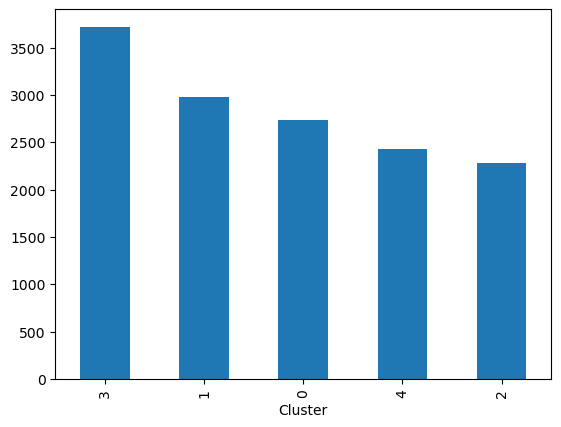

In [87]:
res['Cluster'].value_counts()


# Stacked bar plot of cluster counts
res['Cluster'].value_counts().plot(kind='bar', stacked=True)

In [ ]:
LEE_data = LEE_dat_old
cluster_data = labels_da

    # date_list = []
records = []
for start_str, end_str, esm_run in zip(LEE_data['date_start'], LEE_data['date_end'], LEE_data['ESM_run']):
    start_date = datetime.strptime(start_str, "%Y-%m-%d").date()
    end_date   = datetime.strptime(end_str,   "%Y-%m-%d").date()
    num_days = (end_date - start_date).days + 1
    for offset in range(num_days):
        current = start_date + timedelta(days=offset)
        current64 = np.datetime64(current)  # now datetime64[ns]
        if current.month == 2 and current.day == 29:
            continue
        # current_cftime = cftime.DatetimeNoLeap(current.year, current.month, current.day)

        cluster = cluster_data.sel(time=current64, ESM_run=esm_run).item()
        records.append({"Dates": current.strftime("%Y-%m-%d"), "ESM_run": esm_run, "Cluster": cluster})
res = pd.DataFrame(records)

KeyError: "not all values found in index 'time'. Try setting the `method` keyword argument (example: method='nearest')."

In [49]:
res

,Dates,ESM_run,Cluster
0,2015-01-05,ACCESS-CM2_r1i1p1f1,1
1,2015-01-07,ACCESS-CM2_r1i1p1f1,1
2,2015-01-08,ACCESS-CM2_r1i1p1f1,3
3,2015-01-18,ACCESS-CM2_r1i1p1f1,0
4,2015-01-19,ACCESS-CM2_r1i1p1f1,0
...,...,...,...
12972,2024-12-03,TaiESM1_r1i1p1f1,2
12973,2024-12-06,TaiESM1_r1i1p1f1,4
12974,2024-12-20,TaiESM1_r1i1p1f1,1
12975,2024-12-21,TaiESM1_r1i1p1f1,1


In [48]:
res['Cluster'].value_counts()

Cluster
3    3367
1    2653
0    2617
4    2226
2    2114
Name: count, dtype: int64

In [65]:
LEE_dat_dl = create_date_list(LEE_dat_old, labels_da)


KeyError: "not all values found in index 'time'. Try setting the `method` keyword argument (example: method='nearest')."

In [136]:
LEE_dat_dl = create_date_list(LEE_dat, labels_da)
LEE_7_dl = create_date_list(LEE_7, labels_da)
LEE_14_dl = create_date_list(LEE_14, labels_da)

InvalidIndexError: 2015-01-05 00:00:00

In [74]:
df['cluster'].value_counts()

cluster
3    83543
1    78860
0    63733
2    62583
4    62541
Name: count, dtype: int64

In [72]:
LEE_dat_dl["Cluster"].value_counts()

Cluster
3    9384
0    7712
1    6903
4    5720
2    5498
Name: count, dtype: int64

In [57]:
labels_da.isel(ESM_run=2)[17:20]

<xarray.DataArray 'cluster_id' (time: 3)> Size: 12B
array([0, 0, 0], dtype=int32)
Coordinates:
  * time     (time) object 24B 2015-01-18 00:00:00 ... 2015-01-20 00:00:00
    ESM      (time) <U13 156B dask.array<chunksize=(3,), meta=np.ndarray>
    ESM_run  <U23 92B 'ACCESS-CM2_r1i1p1f1'

In [105]:
LEE_dat

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
0,2015-01-05,2015-01-05,2015-01-05,4,4,4,1,1347.755832,1347.755832,0.0,1347.755832,1,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,5
1,2015-01-07,2015-01-07,2015-01-07,6,6,6,1,1333.134503,1333.134503,0.0,1333.134503,2,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,7
2,2015-01-08,2015-01-08,2015-01-08,7,7,7,1,1395.107358,1395.107358,0.0,1395.107358,3,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,8
3,2015-01-18,2015-01-18,2015-01-18,17,17,17,1,1409.547842,1409.547842,0.0,1409.547842,4,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,18
4,2015-01-19,2015-01-19,2015-01-19,18,18,18,1,1403.974418,1403.974418,0.0,1403.974418,5,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35218,2024-12-20,2024-12-20,2024-12-20,3638,3638,3638,1,1455.111286,1455.111286,0.0,1455.111286,35219,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2024,354
35219,2024-12-21,2024-12-21,2024-12-21,3639,3639,3639,1,1433.341128,1433.341128,0.0,1433.341128,35220,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2024,355
35220,2024-12-25,2024-12-25,2024-12-25,3643,3643,3643,1,1392.939718,1392.939718,0.0,1392.939718,35221,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2024,359
35221,2024-12-30,2024-12-30,2024-12-30,3648,3648,3648,1,1506.619573,1506.619573,0.0,1506.619573,35222,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2024,364


### Plot for event days distributions of cluster for different event lengths

In [54]:
# Compute relative frequencies for each DataFrame
dfs = {
    'Daily': pd.DataFrame(LEE_dat_dl),
    '7-day': pd.DataFrame(LEE_7_dl),
    '14-day': pd.DataFrame(LEE_14_dl)
}

# Get sorted list of all clusters present across datasets
all_clusters = sorted(set().union(*(df['Cluster'].unique() for df in dfs.values())))

# Prepare proportions matrix
data = {
    name: df['Cluster'].value_counts(normalize=True).reindex(all_clusters, fill_value=0)
    for name, df in dfs.items()
}

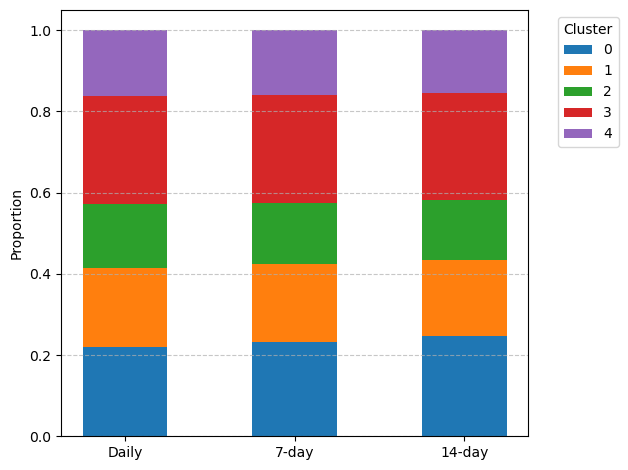

In [55]:
# Plotting
fig, ax = plt.subplots()
bar_width = 0.5
x = np.arange(len(dfs))  # positions for the three bars

# Stack bars
bottom = np.zeros(len(dfs))
for cluster in all_clusters:
    heights = [data[name].get(cluster, 0) for name in dfs]
    ax.bar(x, heights, bar_width, bottom=bottom, label=str(cluster))
    bottom += heights

# Formatting
ax.set_xticks(x)
ax.set_xticklabels(dfs.keys())
ax.set_ylabel('Proportion')
ax.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

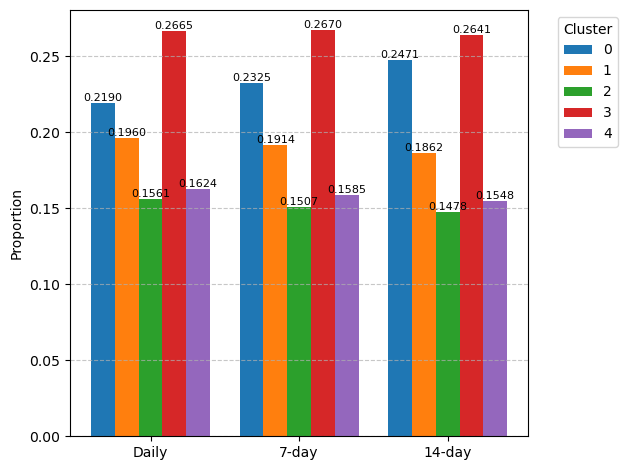

In [93]:
# Plotting
fig, ax = plt.subplots()
num_clusters = len(all_clusters)
bar_width = 0.8 / num_clusters  # make sure total width fits

x = np.arange(len(dfs))  # positions for the main groups

# Plot side-by-side bars
for i, cluster in enumerate(all_clusters):
    heights = [data[name].get(cluster, 0) for name in dfs]
    offset_x = x + i * bar_width - (bar_width * (num_clusters - 1) / 2)  # center the bars
    bars = ax.bar(offset_x, heights, bar_width, label=str(cluster))

    # Add value labels above bars
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{height:.4f}',
            ha='center',
            va='bottom',
            fontsize=8
        )

# Formatting
ax.set_xticks(x)
ax.set_xticklabels(dfs.keys())
ax.set_ylabel('Proportion')
ax.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### Plot clusters against ESM

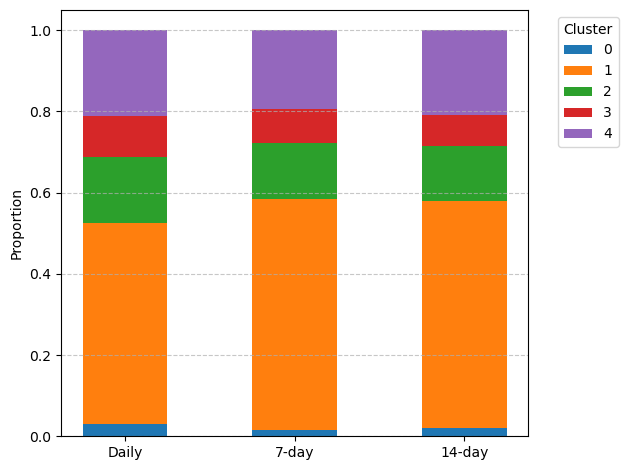

In [77]:
# Plotting
fig, ax = plt.subplots()
bar_width = 0.5
x = np.arange(len(dfs))  # positions for the three bars

# Stack bars
bottom = np.zeros(len(dfs))
for cluster in all_clusters:
    heights = [data[name].get(cluster, 0) for name in dfs]
    ax.bar(x, heights, bar_width, bottom=bottom, label=str(cluster))
    bottom += heights

# Formatting
ax.set_xticks(x)
ax.set_xticklabels(dfs.keys())
ax.set_ylabel('Proportion')
ax.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [60]:
df["ESM"] = (df["ESM_run"].str.split('_')).str[0]

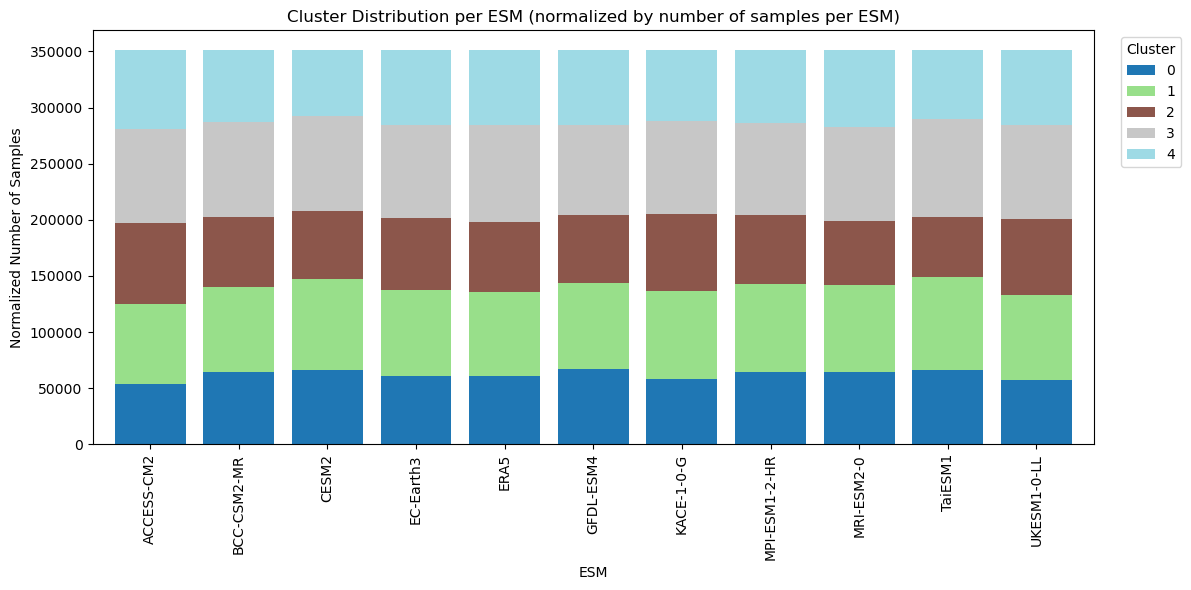

In [62]:
# Make one plot for all ESMs each represented by a stacked barplot normalize by number of samples per ESM
# Calculate the number of samples per ESM
samples_per_esm = df['ESM'].value_counts()
samples_per_esm = samples_per_esm / samples_per_esm.sum()

# Group by ESM and cluster, then count occurrences
esm_cluster_counts = df.groupby(['ESM', 'cluster']).size().unstack(fill_value=0)
esm_cluster_counts = esm_cluster_counts.div(samples_per_esm, axis=0)
esm_cluster_counts.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    colormap="tab20",
    width=0.8
)
plt.xlabel("ESM")
plt.ylabel("Normalized Number of Samples")
plt.title("Cluster Distribution per ESM (normalized by number of samples per ESM)")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Large Plot combined

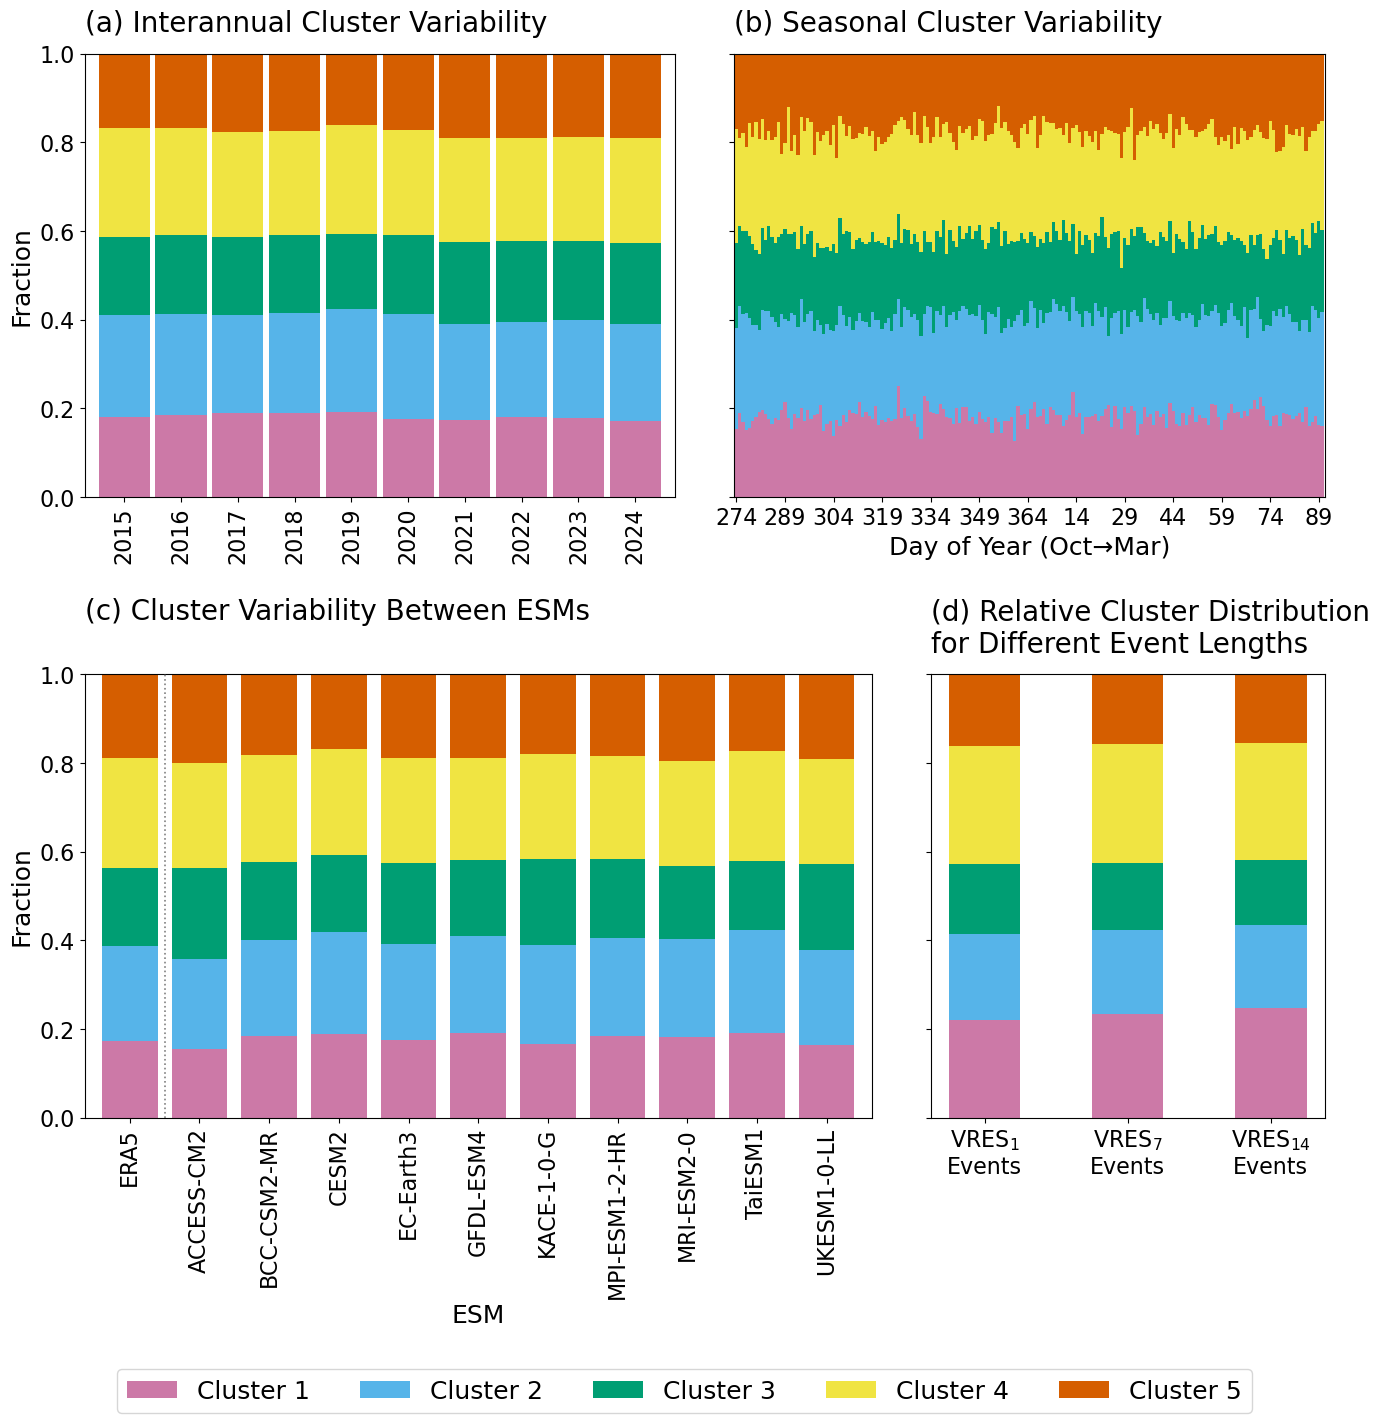

In [68]:
mpl.rcParams.update({
    'font.size': 18,
    'axes.titlesize': 20,
    'axes.labelsize': 18,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 18,
    'figure.titlesize': 20,
})
plt.rcParams['axes.titlepad'] = 16  # default padding for all titles (in points)

# --- palette (re-use your colors) ---
# cluster_colors = ["mediumorchid", "deepskyblue", "forestgreen", "gold", "crimson"]
# colorblind-friendly hex colours (Okabe–Ito subset)
cluster_colors = [
    "#CC79A7",  # purple (replaces mediumorchid)
    "#56B4E9",  # light blue (replaces deepskyblue)
    "#009E73",  # green (replaces forestgreen)
    "#F0E442",  # yellow/gold (replaces gold)
    "#D55E00",  # orange-red (replaces crimson)
]

cluster_palette = {i: c for i, c in enumerate(cluster_colors)}

# Create 2x2 figure
fig = plt.figure(figsize=(16, 14))
# gs = GridSpec(2, 2, figure=fig, hspace=0.2, wspace=0.1)
outer = GridSpec(2, 1, height_ratios=[1, 1], hspace=0.4)  # hspace adjusts the vertical space between the two rows

top = outer[0].subgridspec(1, 2, wspace=0.1)
ax_a = fig.add_subplot(top[0, 0])  # (b) links
ax_b = fig.add_subplot(top[0, 1])  # (c) rechts

# --------------------------
# (a) Top-left: Yearly fractions (stacked bar)
# --------------------------
# ax_a = fig.add_subplot(gs[0, 0])
df_year = yearly_frac.T  # as in your original code

df_year.plot(
    kind="bar", stacked=True, ax=ax_a, width=0.9,
    color=[cluster_palette[int(c)] for c in df_year.columns],
    legend=False
)
ax_a.set_xlabel("")
ax_a.set_ylabel("Fraction")
ax_a.set_ylim(0, 1)
ax_a.set_xticklabels(df_year.index, rotation=90) # , ha="right"
# ax_a.set_title("(a) Yearly fractions", fontsize=20, fontweight='bold', loc='left')
ax_a.set_title("(a) Interannual Cluster Variability", fontsize=20, loc='left')

# --------------------------
# (b) Bottom-left: simple cluster counts bar (replaces the maps)
# --------------------------
# ax_b = fig.add_subplot(gs[0, 1])
days = doy_frac.columns.astype(int)
oct_to_dec = days[(days >= 274) & (days <= 365)]
jan_to_mar = days[(days >= 1) & (days <= 90)]
order = np.concatenate([oct_to_dec, jan_to_mar])
ordered = doy_frac[order]
df_doy = ordered.T

df_doy.plot(
    kind="bar", stacked=True, ax=ax_b, width=1,
    color=[cluster_palette[c] for c in df_doy.columns],
    legend=False
)
ax_b.set_xlabel("Day of Year (Oct→Mar)")
ax_b.set_ylabel("")
# ax_b.set_ylabel("Fraction")
ax_b.set_ylim(0, 1)
ticks = np.arange(len(df_doy.index))[::15]
ax_b.set_xticks(ticks)
ax_b.set_xticklabels(df_doy.index[ticks], rotation=0) #, ha="right"
ax_b.set_yticklabels([])
# fig.text(0.39, 0.57, "(b)", fontsize=20, fontweight="bold")
ax_b.set_title("(b) Seasonal Cluster Variability", fontsize=20, loc='left')


bottom = outer[1].subgridspec(1, 2, width_ratios=[2, 1], wspace=0.1)
ax_c = fig.add_subplot(bottom[0, 0])  # (c) nimmt 2/3 Breite
ax_d = fig.add_subplot(bottom[0, 1])  # (d) nimmt 1/3 Breite
# --------------------------
# (c) Top-right: ESM stacked bar normalized per-ESM
# --------------------------
# ax_c = fig.add_subplot(gs[1, 0])

# Prepare ESM x cluster counts and normalize per ESM to get fractions
esm_cluster_counts = df.groupby(['ESM', 'cluster']).size().unstack(fill_value=0)

# normalize rows so each ESM's stacked bar sums to 1 (fractions per ESM)
esm_cluster_props = esm_cluster_counts.div(esm_cluster_counts.sum(axis=1), axis=0)

# order cluster columns (in case some cluster numbers missing)
ordered_clusters = sorted(esm_cluster_props.columns.astype(int))
esm_cluster_props = esm_cluster_props[ordered_clusters]

# color list matching the ordered clusters
colors_for_esm = [cluster_palette[int(c)] for c in ordered_clusters]

# --- bring ERA5 (case-insensitive) to the front if present ---
era_row = None
for idx in esm_cluster_props.index:
    if 'era' in str(idx).lower():   # findet 'ERA5', 'era5', 'ERA-5', 'era_5' etc.
        era_row = idx
        break

new_order = [era_row] + [i for i in esm_cluster_props.index if i != era_row]
esm_to_plot = esm_cluster_props.loc[new_order]

# plot
esm_to_plot.plot(
    kind="bar",
    stacked=True,
    ax=ax_c,
    width=0.8,
    color=colors_for_esm,
    legend=False
)
ax_c.set_xlabel("ESM")
ax_c.set_ylabel("Fraction")
ax_c.set_ylim(0, 1)
ax_c.set_title("(c) Cluster Variability Between ESMs\n", fontsize=20, loc='left')

# rotate xticks vertically for readability
ax_c.set_xticklabels(ax_c.get_xticklabels(), rotation=90)

# draw vertical grey dotted separator after the first bar if ERA was moved to front
# Bars are centered at x = 0,1,2,... so separator between first and second is at x = 0.5
sep_x = 0.5
ax_c.axvline(x=sep_x, color='gray', linestyle=':', linewidth=1.2, zorder=10)


# --------------------------
# (d) Bottom-right: relative cluster distribution for 1/7/14-day events (your original logic)
# --------------------------
# ax_d = fig.add_subplot(gs[1, 1])
dfs = {
    r'$\mathrm{VRES}_{1}$' + '\n' + 'Events': pd.DataFrame(LEE_dat_dl),
    r'$\mathrm{VRES}_{7}$' + '\n' + 'Events': pd.DataFrame(LEE_7_dl),
    r'$\mathrm{VRES}_{14}$' + '\n' + 'Events': pd.DataFrame(LEE_14_dl)
}

all_clusters = sorted(set().union(*(df_['Cluster'].unique() for df_ in dfs.values())))
data = {
    name: df_['Cluster'].value_counts(normalize=True).reindex(all_clusters, fill_value=0)
    for name, df_ in dfs.items()
}

bar_width = 0.5
x = np.arange(len(dfs))
bottom = np.zeros(len(dfs))
for cluster in all_clusters:
    heights = [data[name].get(cluster, 0) for name in dfs]
    ax_d.bar(x, heights, bar_width, bottom=bottom, label=f"Cluster {int(cluster)+1}", color=cluster_palette[int(cluster)])
    bottom += heights

ax_d.set_xticks(x)
ax_d.set_xticklabels(list(dfs.keys()), rotation=0)
ax_d.set_yticklabels([])
ax_d.set_ylabel('')
ax_d.set_ylim(0, 1)
# ax_d.set_title("(d) Relative cluster distribution (1/7/14-day)", fontsize=20, loc='left')
ax_d.set_title("(d) Relative Cluster Distribution \nfor Different Event Lengths", fontsize=20, loc='left')

# --------------------------
# Global legend (lower center) using consistent cluster handles
# --------------------------
legend_handles = [
    Patch(facecolor=cluster_palette[int(c)], label=f"Cluster {int(c)+1}")
    for c in all_clusters
]

fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=len(all_clusters),
    bbox_to_anchor=(0.5, -0.1),
    frameon=True
)

# final layout tweak and show
fig.subplots_adjust(bottom=0.12)
# fig.savefig('/home/onennecke/Code/Figures/cluster_analysis_2x2.png', dpi=300, bbox_inches='tight')

plt.show()


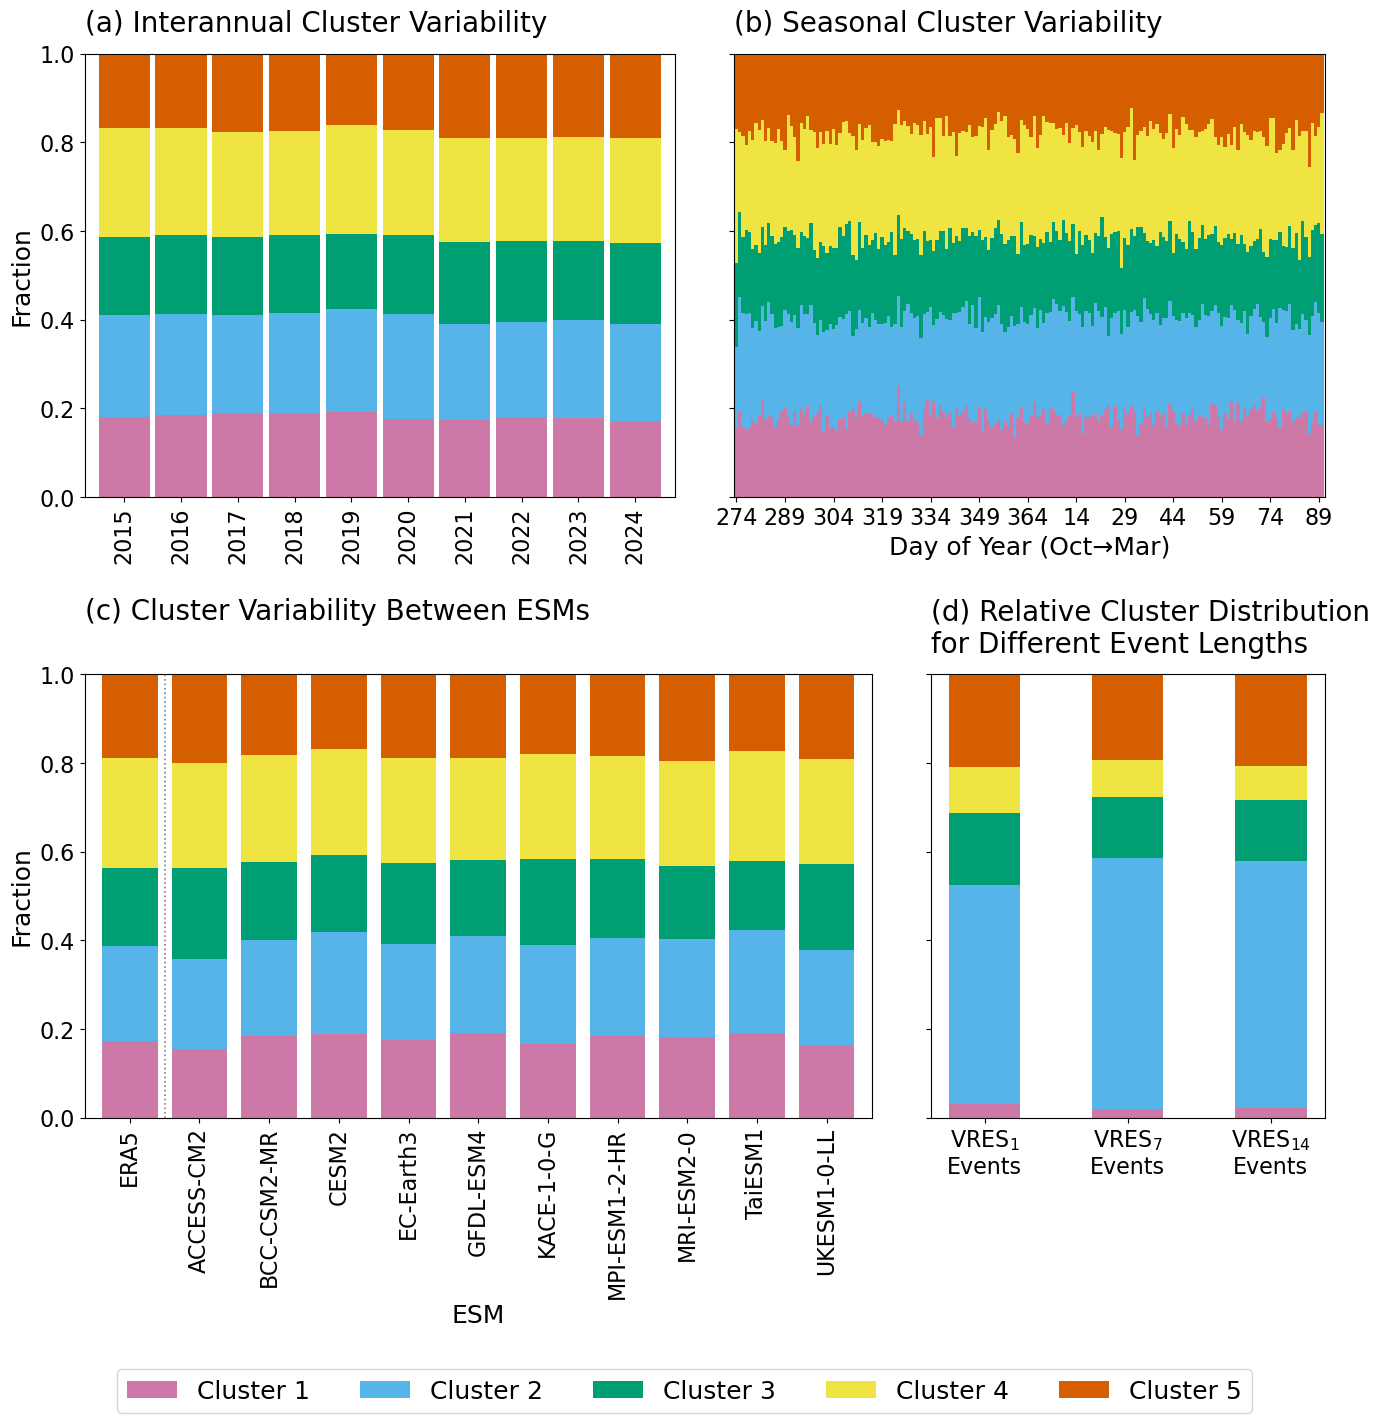

In [79]:
mpl.rcParams.update({
    'font.size': 18,
    'axes.titlesize': 20,
    'axes.labelsize': 18,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 18,
    'figure.titlesize': 20,
})
plt.rcParams['axes.titlepad'] = 16  # default padding for all titles (in points)

# --- palette (re-use your colors) ---
# cluster_colors = ["mediumorchid", "deepskyblue", "forestgreen", "gold", "crimson"]
# colorblind-friendly hex colours (Okabe–Ito subset)
cluster_colors = [
    "#CC79A7",  # purple (replaces mediumorchid)
    "#56B4E9",  # light blue (replaces deepskyblue)
    "#009E73",  # green (replaces forestgreen)
    "#F0E442",  # yellow/gold (replaces gold)
    "#D55E00",  # orange-red (replaces crimson)
]

cluster_palette = {i: c for i, c in enumerate(cluster_colors)}

# Create 2x2 figure
fig = plt.figure(figsize=(16, 14))
# gs = GridSpec(2, 2, figure=fig, hspace=0.2, wspace=0.1)
outer = GridSpec(2, 1, height_ratios=[1, 1], hspace=0.4)  # hspace adjusts the vertical space between the two rows

top = outer[0].subgridspec(1, 2, wspace=0.1)
ax_a = fig.add_subplot(top[0, 0])  # (b) links
ax_b = fig.add_subplot(top[0, 1])  # (c) rechts

# --------------------------
# (a) Top-left: Yearly fractions (stacked bar)
# --------------------------
# ax_a = fig.add_subplot(gs[0, 0])
df_year = yearly_frac.T  # as in your original code

df_year.plot(
    kind="bar", stacked=True, ax=ax_a, width=0.9,
    color=[cluster_palette[int(c)] for c in df_year.columns],
    legend=False
)
ax_a.set_xlabel("")
ax_a.set_ylabel("Fraction")
ax_a.set_ylim(0, 1)
ax_a.set_xticklabels(df_year.index, rotation=90) # , ha="right"
# ax_a.set_title("(a) Yearly fractions", fontsize=20, fontweight='bold', loc='left')
ax_a.set_title("(a) Interannual Cluster Variability", fontsize=20, loc='left')

# --------------------------
# (b) Bottom-left: simple cluster counts bar (replaces the maps)
# --------------------------
# ax_b = fig.add_subplot(gs[0, 1])
days = doy_frac.columns.astype(int)
oct_to_dec = days[(days >= 274) & (days <= 365)]
jan_to_mar = days[(days >= 1) & (days <= 90)]
order = np.concatenate([oct_to_dec, jan_to_mar])
ordered = doy_frac[order]
df_doy = ordered.T

df_doy.plot(
    kind="bar", stacked=True, ax=ax_b, width=1,
    color=[cluster_palette[c] for c in df_doy.columns],
    legend=False
)
ax_b.set_xlabel("Day of Year (Oct→Mar)")
ax_b.set_ylabel("")
# ax_b.set_ylabel("Fraction")
ax_b.set_ylim(0, 1)
ticks = np.arange(len(df_doy.index))[::15]
ax_b.set_xticks(ticks)
ax_b.set_xticklabels(df_doy.index[ticks], rotation=0) #, ha="right"
ax_b.set_yticklabels([])
# fig.text(0.39, 0.57, "(b)", fontsize=20, fontweight="bold")
ax_b.set_title("(b) Seasonal Cluster Variability", fontsize=20, loc='left')


bottom = outer[1].subgridspec(1, 2, width_ratios=[2, 1], wspace=0.1)
ax_c = fig.add_subplot(bottom[0, 0])  # (c) nimmt 2/3 Breite
ax_d = fig.add_subplot(bottom[0, 1])  # (d) nimmt 1/3 Breite
# --------------------------
# (c) Top-right: ESM stacked bar normalized per-ESM
# --------------------------
# ax_c = fig.add_subplot(gs[1, 0])

# Prepare ESM x cluster counts and normalize per ESM to get fractions
esm_cluster_counts = df.groupby(['ESM', 'cluster']).size().unstack(fill_value=0)

# normalize rows so each ESM's stacked bar sums to 1 (fractions per ESM)
esm_cluster_props = esm_cluster_counts.div(esm_cluster_counts.sum(axis=1), axis=0)

# order cluster columns (in case some cluster numbers missing)
ordered_clusters = sorted(esm_cluster_props.columns.astype(int))
esm_cluster_props = esm_cluster_props[ordered_clusters]

# color list matching the ordered clusters
colors_for_esm = [cluster_palette[int(c)] for c in ordered_clusters]

# --- bring ERA5 (case-insensitive) to the front if present ---
era_row = None
for idx in esm_cluster_props.index:
    if 'era' in str(idx).lower():   # findet 'ERA5', 'era5', 'ERA-5', 'era_5' etc.
        era_row = idx
        break

new_order = [era_row] + [i for i in esm_cluster_props.index if i != era_row]
esm_to_plot = esm_cluster_props.loc[new_order]

# plot
esm_to_plot.plot(
    kind="bar",
    stacked=True,
    ax=ax_c,
    width=0.8,
    color=colors_for_esm,
    legend=False
)
ax_c.set_xlabel("ESM")
ax_c.set_ylabel("Fraction")
ax_c.set_ylim(0, 1)
ax_c.set_title("(c) Cluster Variability Between ESMs\n", fontsize=20, loc='left')

# rotate xticks vertically for readability
ax_c.set_xticklabels(ax_c.get_xticklabels(), rotation=90)

# draw vertical grey dotted separator after the first bar if ERA was moved to front
# Bars are centered at x = 0,1,2,... so separator between first and second is at x = 0.5
sep_x = 0.5
ax_c.axvline(x=sep_x, color='gray', linestyle=':', linewidth=1.2, zorder=10)


# --------------------------
# (d) Bottom-right: relative cluster distribution for 1/7/14-day events (your original logic)
# --------------------------
# ax_d = fig.add_subplot(gs[1, 1])
dfs = {
    r'$\mathrm{VRES}_{1}$' + '\n' + 'Events': pd.DataFrame(LEE_dat_dl),
    r'$\mathrm{VRES}_{7}$' + '\n' + 'Events': pd.DataFrame(LEE_7_dl),
    r'$\mathrm{VRES}_{14}$' + '\n' + 'Events': pd.DataFrame(LEE_14_dl)
}

all_clusters = sorted(set().union(*(df_['Cluster'].unique() for df_ in dfs.values())))
data = {
    name: df_['Cluster'].value_counts(normalize=True).reindex(all_clusters, fill_value=0)
    for name, df_ in dfs.items()
}

bar_width = 0.5
x = np.arange(len(dfs))
bottom = np.zeros(len(dfs))
for cluster in all_clusters:
    heights = [data[name].get(cluster, 0) for name in dfs]
    ax_d.bar(x, heights, bar_width, bottom=bottom, label=f"Cluster {int(cluster)+1}", color=cluster_palette[int(cluster)])
    bottom += heights

ax_d.set_xticks(x)
ax_d.set_xticklabels(list(dfs.keys()), rotation=0)
ax_d.set_yticklabels([])
ax_d.set_ylabel('')
ax_d.set_ylim(0, 1)
# ax_d.set_title("(d) Relative cluster distribution (1/7/14-day)", fontsize=20, loc='left')
ax_d.set_title("(d) Relative Cluster Distribution \nfor Different Event Lengths", fontsize=20, loc='left')

# --------------------------
# Global legend (lower center) using consistent cluster handles
# --------------------------
legend_handles = [
    Patch(facecolor=cluster_palette[int(c)], label=f"Cluster {int(c)+1}")
    for c in all_clusters
]

fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=len(all_clusters),
    bbox_to_anchor=(0.5, -0.1),
    frameon=True
)

# final layout tweak and show
fig.subplots_adjust(bottom=0.12)
# fig.savefig('/home/onennecke/Code/Figures/cluster_analysis_2x2.png', dpi=300, bbox_inches='tight')

plt.show()


In [69]:
cluster_counts

cluster
3    83543
1    78860
0    63733
2    62583
4    62541
Name: count, dtype: int64

In [80]:
cluster_counts

cluster
3    83543
1    78860
0    63733
2    62583
4    62541
Name: count, dtype: int64

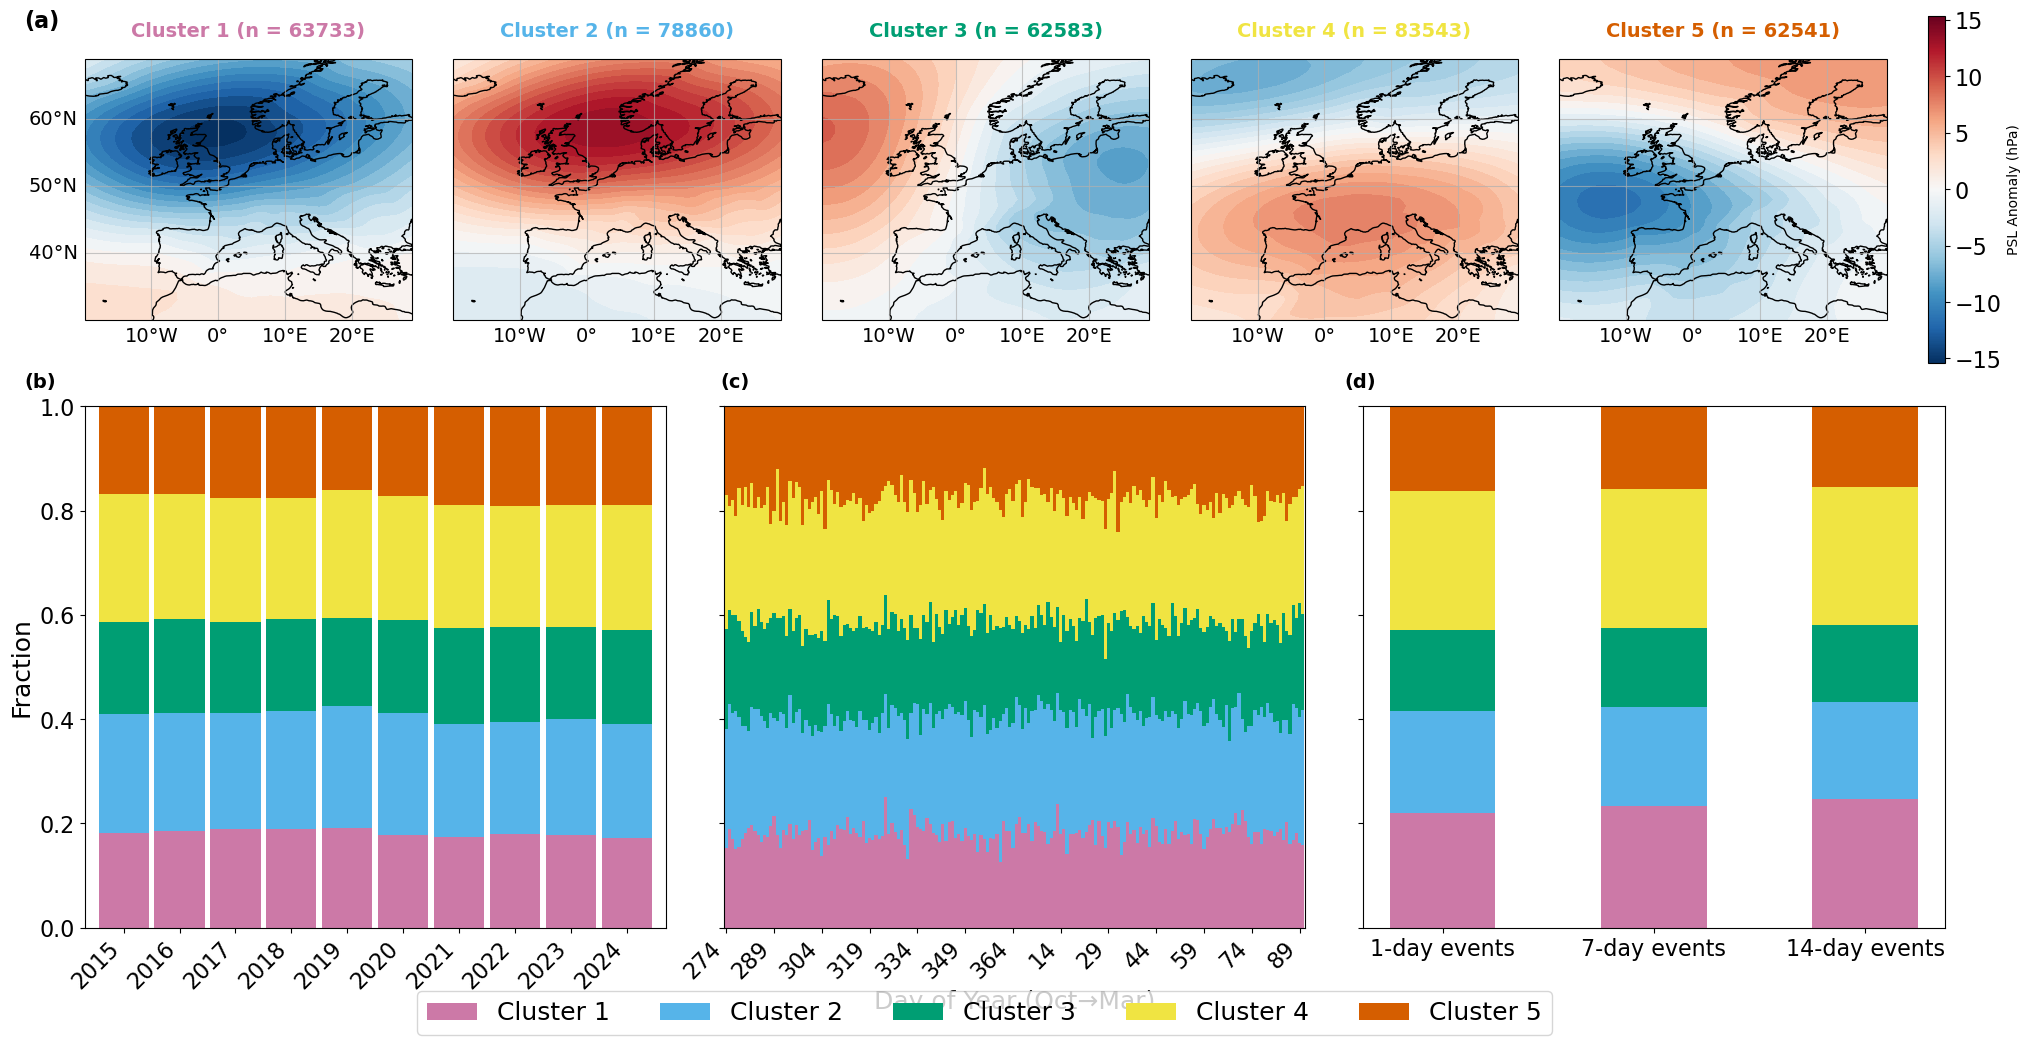

In [70]:
# Create a color palette for clusters
# cluster_colors = ["mediumorchid", "deepskyblue", "forestgreen", "gold", "crimson"]
cluster_colors = [
    "#CC79A7",  # purple (replaces mediumorchid)
    "#56B4E9",  # light blue (replaces deepskyblue)
    "#009E73",  # green (replaces forestgreen)
    "#F0E442",  # yellow/gold (replaces gold)
    "#D55E00",  # orange-red (replaces crimson)
]
cluster_palette = {i: c for i, c in enumerate(cluster_colors)}

# global vmin/vmax
vmin = np.nanmin(centroids_reshaped / 100.0)
vmax = -vmin

# create figure & top‐level 2×1 GridSpec
fig = plt.figure(figsize=(24, 12))                              # Adjust size of the figure
outer_gs = GridSpec(2, 1, height_ratios=[2, 3], hspace=0.1)     # Create outer GridSpec with 2 rows, 1 column, and space between rows

# --- ROW 1: five maps + colorbar in a 1×6 sub‐GridSpec ---
row1 = outer_gs[0].subgridspec(1, 6, width_ratios=[1,1,1,1,1,0.05], wspace=0.15) # Create sub‐GridSpec for row 1 with 6 columns (5 maps + colorbar)
lons = ((ts_datasets['lon'].values + 180) % 360) - 180
lats = ts_datasets['lat'].values
for i in range(5):  # Loop through each cluster                             # Plot each cluster in a separate subplot
    ax = fig.add_subplot(row1[0, i], projection=ccrs.PlateCarree())
    cf = ax.contourf(
        lons, lats, (centroids_reshaped[i] / 100.0),
        levels=20, vmin=vmin, vmax=vmax,
        cmap="RdBu_r", transform=ccrs.PlateCarree()
    )
    ax.coastlines()
    if i == 0:
        setup_gridlines(ax, deg=10, alpha=0.7)
    else:
        setup_gridlines(ax, deg=10, alpha=0.7, ll=False)
    ax.set_title(f"Cluster {i+1} (n = {cluster_counts[i]})", color=cluster_colors[i], fontsize=14, fontweight='bold')
# colorbar
tnorm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = ScalarMappable(norm=tnorm, cmap=cf.cmap)
sm.set_array([])
cax = fig.add_subplot(row1[0, 5])
cbar = plt.colorbar(sm, cax=cax)
cbar.set_label('PSL Anomaly (hPa)', fontsize=10)
fig.text(0.1, 0.87, "(a)", fontsize=16, fontweight='bold')

# --- ROW 2: three panels (b),(c),(d) in a 1×3 sub‐GridSpec ---
row2 = outer_gs[1].subgridspec(1, 3, wspace=0.1)
# (b) Yearly fractions
axb = fig.add_subplot(row2[0, 0])
df_year = yearly_frac.T

df_year.plot(
    kind="bar", stacked=True, ax=axb, width=0.9,
    color=[cluster_palette[c] for c in df_year.columns],
    legend=False
)
axb.set_xlabel("")
axb.set_ylabel("Fraction")
axb.set_ylim(0, 1)
axb.set_xticklabels(df_year.index, rotation=45, ha="right")
fig.text(0.1, 0.57, "(b)", fontsize=14, fontweight="bold")

# (c) Day‐of‐Year Oct→Mar via pandas, shifted to middle
axc = fig.add_subplot(row2[0, 1])
days = doy_frac.columns.astype(int)
oct_to_dec = days[(days >= 274) & (days <= 365)]
jan_to_mar = days[(days >= 1) & (days <= 90)]
order = np.concatenate([oct_to_dec, jan_to_mar])
ordered = doy_frac[order]
df_doy = ordered.T

df_doy.plot(
    kind="bar", stacked=True, ax=axc, width=1,
    color=[cluster_palette[c] for c in df_doy.columns],
    legend=False
)
axc.set_xlabel("Day of Year (Oct→Mar)")
axc.set_ylabel("")
axc.set_ylim(0, 1)
ticks = np.arange(len(df_doy.index))[::15]
axc.set_xticks(ticks)
axc.set_xticklabels(df_doy.index[ticks], rotation=45, ha="right")
axc.set_yticklabels([])
fig.text(0.39, 0.57, "(c)", fontsize=14, fontweight="bold")

# (d) Relative cluster distribution for daily, 7-day, 14-day
axd = fig.add_subplot(row2[0, 2])
# Assuming LEE_dat_dl, LEE_7_dl, LEE_14_dl DataFrames exist with 'Cluster'
dfs = {
    '1-day events': pd.DataFrame(LEE_dat_dl),
    '7-day events': pd.DataFrame(LEE_7_dl),
    '14-day events': pd.DataFrame(LEE_14_dl)
}
all_clusters = sorted(set().union(*(df['Cluster'].unique() for df in dfs.values())))
data = {
    name: df['Cluster'].value_counts(normalize=True).reindex(all_clusters, fill_value=0)
    for name, df in dfs.items()
}
bar_width = 0.5
x = np.arange(len(dfs))
bottom = np.zeros(len(dfs))
for cluster in all_clusters:
    heights = [data[name].get(cluster, 0) for name in dfs]
    axd.bar(x, heights, bar_width, bottom=bottom, label=f"Cluster {cluster+1}", color=cluster_palette[cluster])
    bottom += heights
axd.set_xticks(x)
axd.set_xticklabels(dfs.keys())
axd.set_yticklabels([])
axd.set_ylabel('')
axd.set_ylim(0, 1)
# axd.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
# Create handles/labels for legend manually
legend_handles = [
    Patch(facecolor=cluster_palette[c], label=f"Cluster {c+1}")
    for c in all_clusters
]

# Horizontal legend below all subplots
fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=len(all_clusters),
    bbox_to_anchor=(0.5, 0.02),
    title=''
)

fig.text(0.65, 0.57, "(d)", fontsize=14, fontweight="bold")

# adjust bottom for legend
fig.subplots_adjust(bottom=0.12)
plt.show()

# Save Plot
# fig.savefig('/home/onennecke/Code/Figures/cluster_analysis_combined.png', dpi=300, bbox_inches='tight')


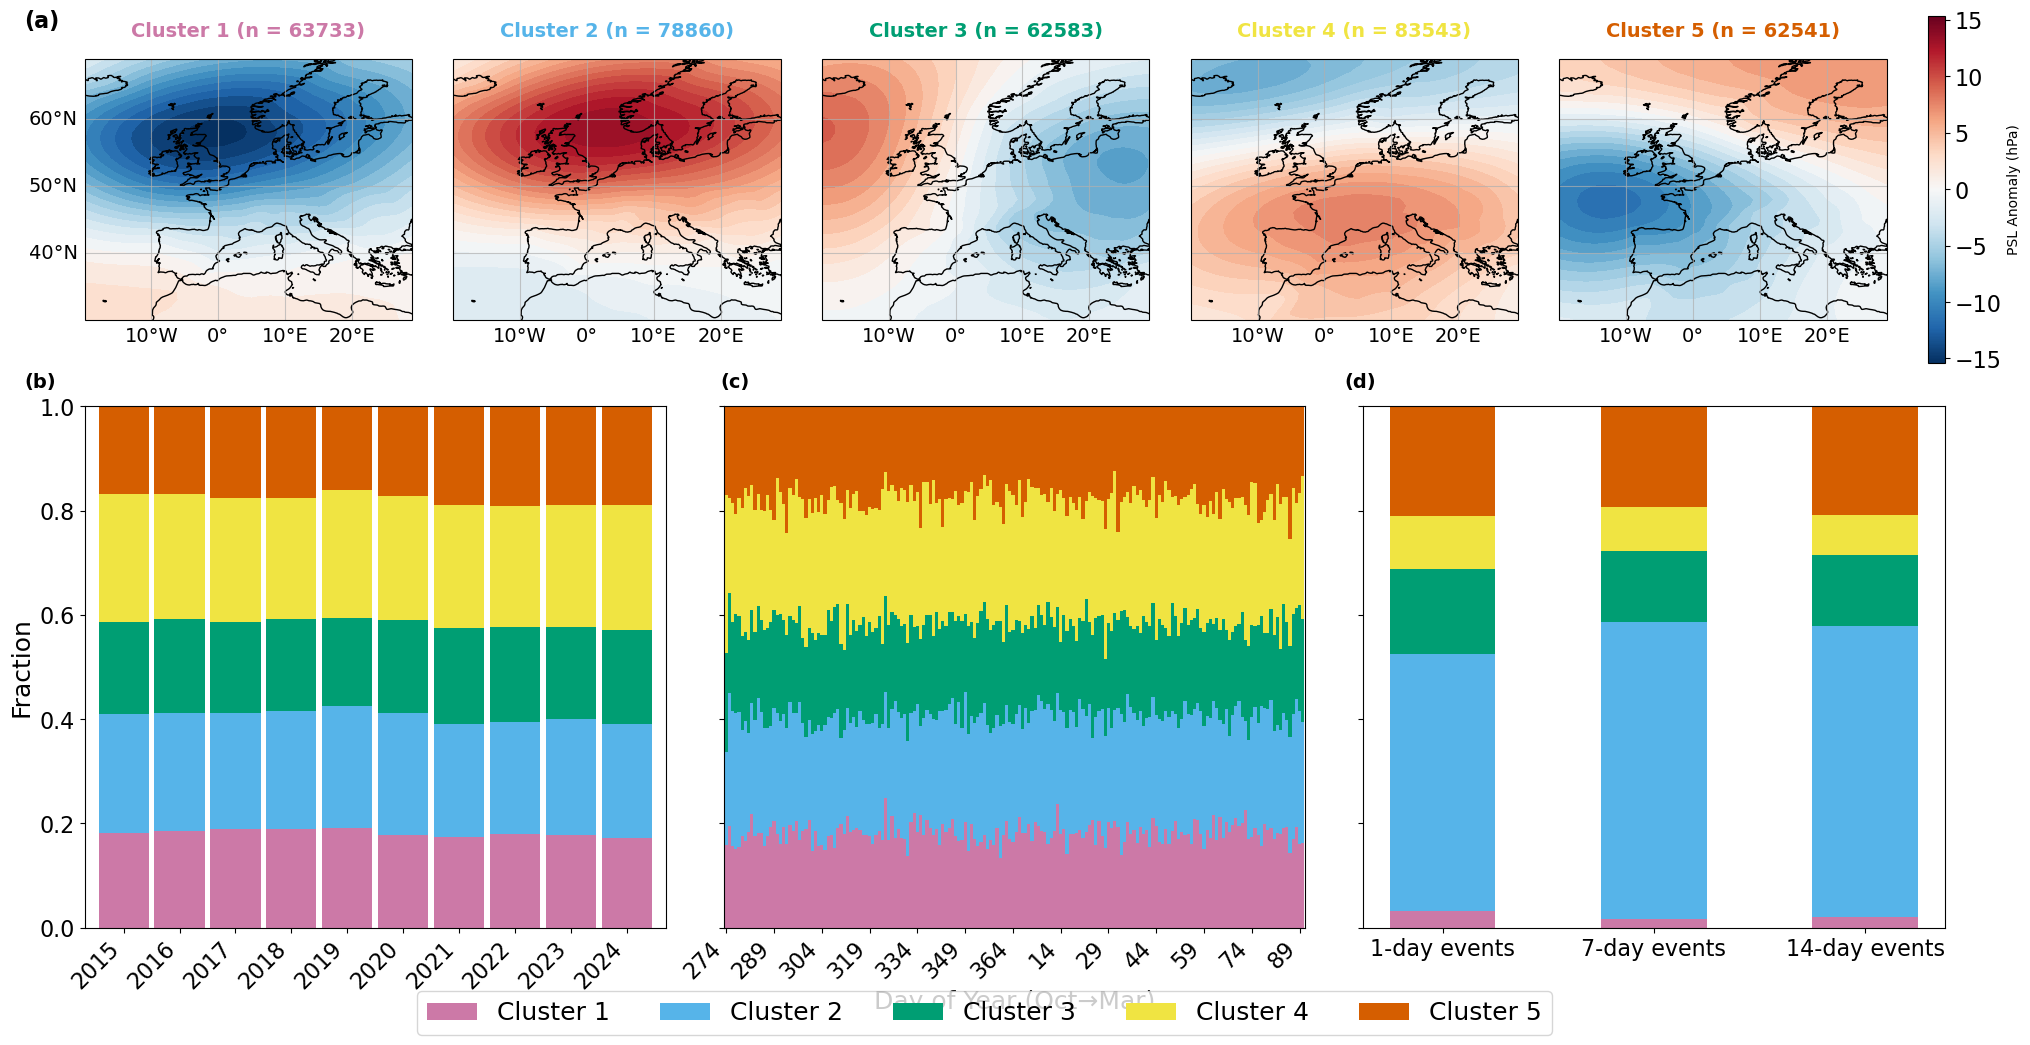

In [81]:
# Create a color palette for clusters
# cluster_colors = ["mediumorchid", "deepskyblue", "forestgreen", "gold", "crimson"]
cluster_colors = [
    "#CC79A7",  # purple (replaces mediumorchid)
    "#56B4E9",  # light blue (replaces deepskyblue)
    "#009E73",  # green (replaces forestgreen)
    "#F0E442",  # yellow/gold (replaces gold)
    "#D55E00",  # orange-red (replaces crimson)
]
cluster_palette = {i: c for i, c in enumerate(cluster_colors)}

# global vmin/vmax
vmin = np.nanmin(centroids_reshaped / 100.0)
vmax = -vmin

# create figure & top‐level 2×1 GridSpec
fig = plt.figure(figsize=(24, 12))                              # Adjust size of the figure
outer_gs = GridSpec(2, 1, height_ratios=[2, 3], hspace=0.1)     # Create outer GridSpec with 2 rows, 1 column, and space between rows

# --- ROW 1: five maps + colorbar in a 1×6 sub‐GridSpec ---
row1 = outer_gs[0].subgridspec(1, 6, width_ratios=[1,1,1,1,1,0.05], wspace=0.15) # Create sub‐GridSpec for row 1 with 6 columns (5 maps + colorbar)
lons = ((ts_datasets['lon'].values + 180) % 360) - 180
lats = ts_datasets['lat'].values
for i in range(5):  # Loop through each cluster                             # Plot each cluster in a separate subplot
    ax = fig.add_subplot(row1[0, i], projection=ccrs.PlateCarree())
    cf = ax.contourf(
        lons, lats, (centroids_reshaped[i] / 100.0),
        levels=20, vmin=vmin, vmax=vmax,
        cmap="RdBu_r", transform=ccrs.PlateCarree()
    )
    ax.coastlines()
    if i == 0:
        setup_gridlines(ax, deg=10, alpha=0.7)
    else:
        setup_gridlines(ax, deg=10, alpha=0.7, ll=False)
    ax.set_title(f"Cluster {i+1} (n = {cluster_counts[i]})", color=cluster_colors[i], fontsize=14, fontweight='bold')
# colorbar
tnorm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = ScalarMappable(norm=tnorm, cmap=cf.cmap)
sm.set_array([])
cax = fig.add_subplot(row1[0, 5])
cbar = plt.colorbar(sm, cax=cax)
cbar.set_label('PSL Anomaly (hPa)', fontsize=10)
fig.text(0.1, 0.87, "(a)", fontsize=16, fontweight='bold')

# --- ROW 2: three panels (b),(c),(d) in a 1×3 sub‐GridSpec ---
row2 = outer_gs[1].subgridspec(1, 3, wspace=0.1)
# (b) Yearly fractions
axb = fig.add_subplot(row2[0, 0])
df_year = yearly_frac.T

df_year.plot(
    kind="bar", stacked=True, ax=axb, width=0.9,
    color=[cluster_palette[c] for c in df_year.columns],
    legend=False
)
axb.set_xlabel("")
axb.set_ylabel("Fraction")
axb.set_ylim(0, 1)
axb.set_xticklabels(df_year.index, rotation=45, ha="right")
fig.text(0.1, 0.57, "(b)", fontsize=14, fontweight="bold")

# (c) Day‐of‐Year Oct→Mar via pandas, shifted to middle
axc = fig.add_subplot(row2[0, 1])
days = doy_frac.columns.astype(int)
oct_to_dec = days[(days >= 274) & (days <= 365)]
jan_to_mar = days[(days >= 1) & (days <= 90)]
order = np.concatenate([oct_to_dec, jan_to_mar])
ordered = doy_frac[order]
df_doy = ordered.T

df_doy.plot(
    kind="bar", stacked=True, ax=axc, width=1,
    color=[cluster_palette[c] for c in df_doy.columns],
    legend=False
)
axc.set_xlabel("Day of Year (Oct→Mar)")
axc.set_ylabel("")
axc.set_ylim(0, 1)
ticks = np.arange(len(df_doy.index))[::15]
axc.set_xticks(ticks)
axc.set_xticklabels(df_doy.index[ticks], rotation=45, ha="right")
axc.set_yticklabels([])
fig.text(0.39, 0.57, "(c)", fontsize=14, fontweight="bold")

# (d) Relative cluster distribution for daily, 7-day, 14-day
axd = fig.add_subplot(row2[0, 2])
# Assuming LEE_dat_dl, LEE_7_dl, LEE_14_dl DataFrames exist with 'Cluster'
dfs = {
    '1-day events': pd.DataFrame(LEE_dat_dl),
    '7-day events': pd.DataFrame(LEE_7_dl),
    '14-day events': pd.DataFrame(LEE_14_dl)
}
all_clusters = sorted(set().union(*(df['Cluster'].unique() for df in dfs.values())))
data = {
    name: df['Cluster'].value_counts(normalize=True).reindex(all_clusters, fill_value=0)
    for name, df in dfs.items()
}
bar_width = 0.5
x = np.arange(len(dfs))
bottom = np.zeros(len(dfs))
for cluster in all_clusters:
    heights = [data[name].get(cluster, 0) for name in dfs]
    axd.bar(x, heights, bar_width, bottom=bottom, label=f"Cluster {cluster+1}", color=cluster_palette[cluster])
    bottom += heights
axd.set_xticks(x)
axd.set_xticklabels(dfs.keys())
axd.set_yticklabels([])
axd.set_ylabel('')
axd.set_ylim(0, 1)
# axd.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
# Create handles/labels for legend manually
legend_handles = [
    Patch(facecolor=cluster_palette[c], label=f"Cluster {c+1}")
    for c in all_clusters
]

# Horizontal legend below all subplots
fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=len(all_clusters),
    bbox_to_anchor=(0.5, 0.02),
    title=''
)

fig.text(0.65, 0.57, "(d)", fontsize=14, fontweight="bold")

# adjust bottom for legend
fig.subplots_adjust(bottom=0.12)
plt.show()

# Save Plot
# fig.savefig('/home/onennecke/Code/Figures/cluster_analysis_combined.png', dpi=300, bbox_inches='tight')


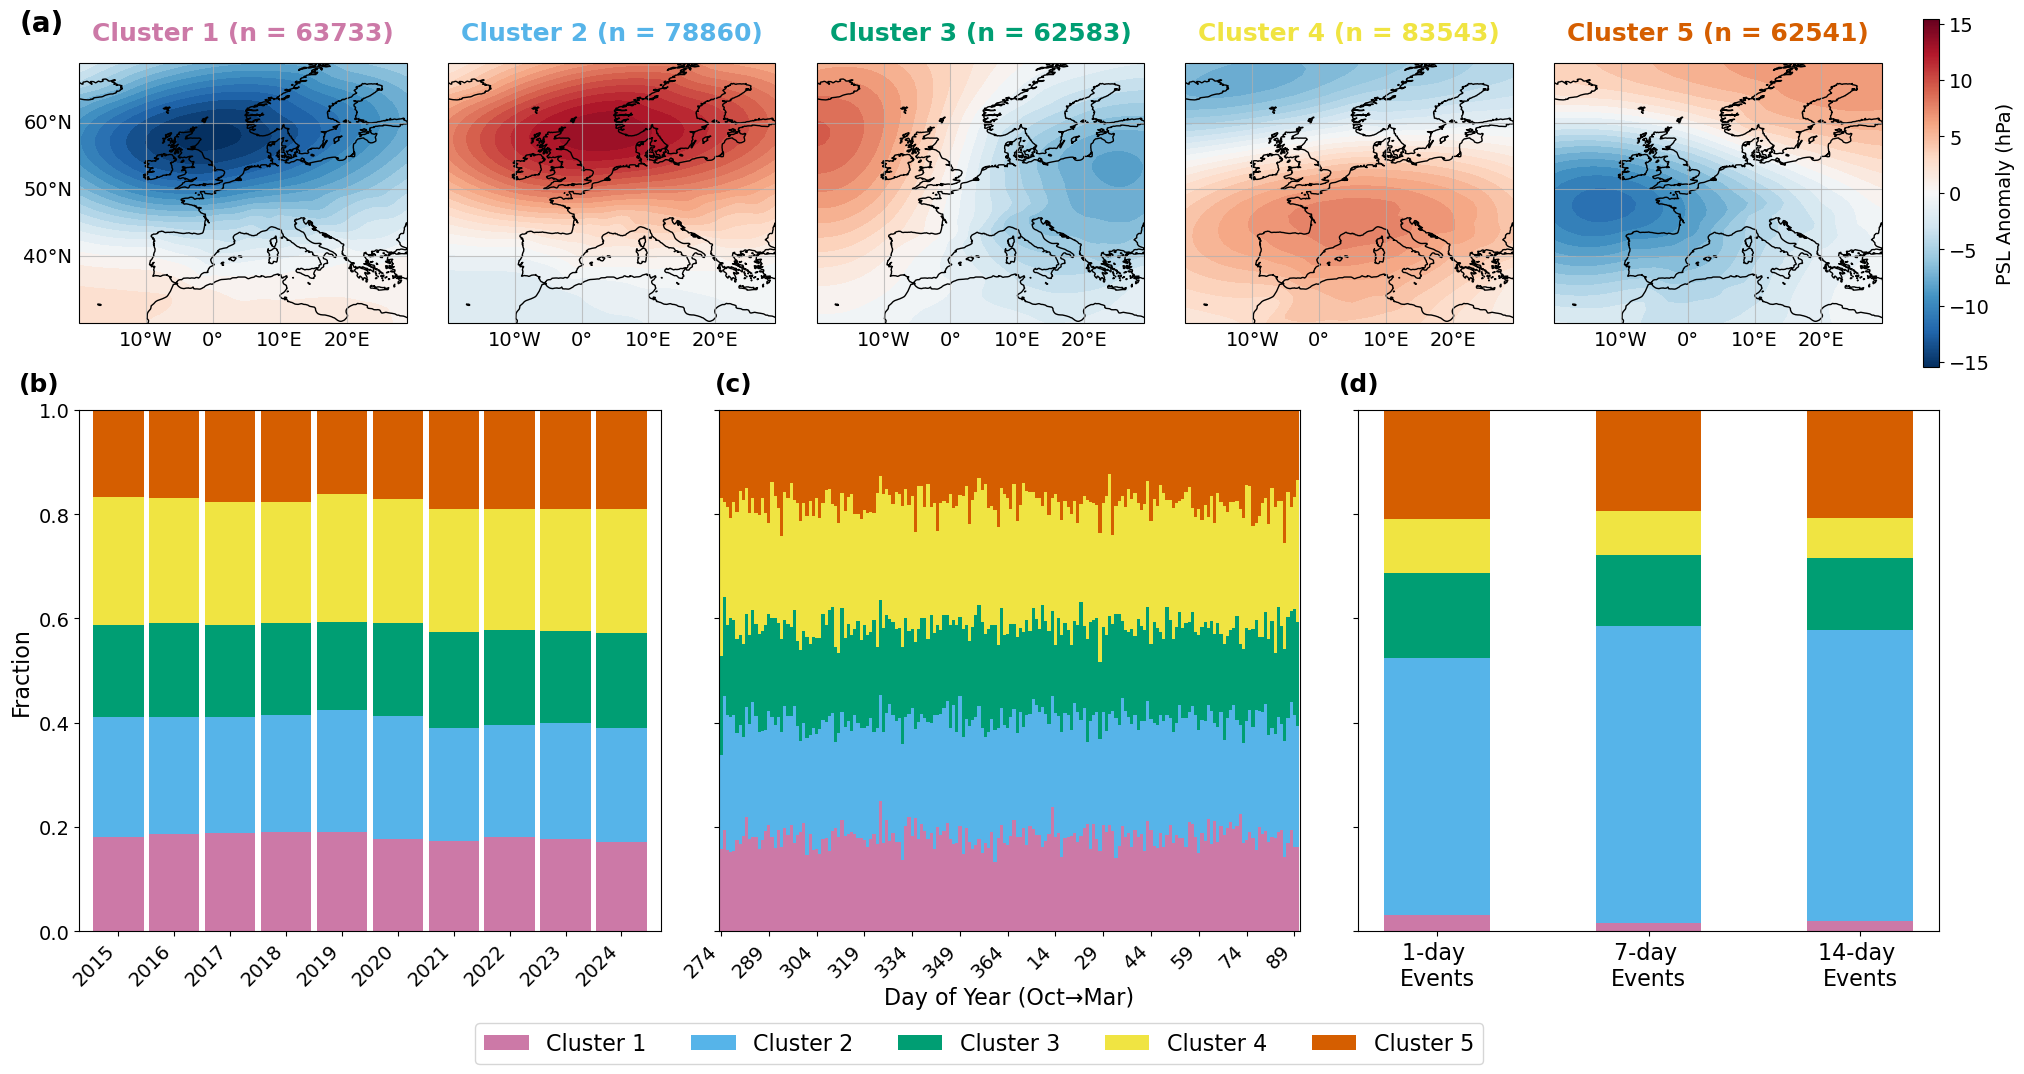

In [82]:
# --- Make all text bigger (global defaults) ---
mpl.rcParams.update({
    'font.size': 16,           # base font size
    'axes.titlesize': 18,      # axes titles
    'axes.labelsize': 16,      # x/y labels
    'xtick.labelsize': 14,     # x tick labels
    'ytick.labelsize': 14,     # y tick labels
    'legend.fontsize': 16,     # legend text
    'figure.titlesize': 18,    # figure title (if used)
})

# Create a color palette for clusters
cluster_colors = ["mediumorchid", "deepskyblue", "forestgreen", "gold", "crimson"]
cluster_colors = [
    "#CC79A7",  # purple (replaces mediumorchid)
    "#56B4E9",  # light blue (replaces deepskyblue)
    "#009E73",  # green (replaces forestgreen)
    "#F0E442",  # yellow/gold (replaces gold)
    "#D55E00",  # orange-red (replaces crimson)
]
cluster_palette = {i: c for i, c in enumerate(cluster_colors)}

# global vmin/vmax
vmin = np.nanmin(centroids_reshaped / 100.0)
vmax = -vmin

# create figure & top‐level 2×1 GridSpec
fig = plt.figure(figsize=(24, 12))                              # Adjust size of the figure
outer_gs = GridSpec(2, 1, height_ratios=[2, 3], hspace=0.1)     # Create outer GridSpec with 2 rows, 1 column, and space between rows

# --- ROW 1: five maps + colorbar in a 1×6 sub‐GridSpec ---
row1 = outer_gs[0].subgridspec(1, 6, width_ratios=[1,1,1,1,1,0.05], wspace=0.15) # Create sub‐GridSpec for row 1 with 6 columns (5 maps + colorbar)
lons = ((ts_datasets['lon'].values + 180) % 360) - 180
lats = ts_datasets['lat'].values
for i in range(5):  # Loop through each cluster                             # Plot each cluster in a separate subplot
    ax = fig.add_subplot(row1[0, i], projection=ccrs.PlateCarree())
    cf = ax.contourf(
        lons, lats, (centroids_reshaped[i] / 100.0),
        levels=20, vmin=vmin, vmax=vmax,
        cmap="RdBu_r", transform=ccrs.PlateCarree()
    )
    ax.coastlines()
    if i == 0:
        setup_gridlines(ax, deg=10, alpha=0.7)
    else:
        setup_gridlines(ax, deg=10, alpha=0.7, ll=False)
    ax.set_title(f"Cluster {i+1} (n = {cluster_counts[i]})", color=cluster_colors[i],
                 fontsize=18, fontweight='bold')   # increased title fontsize
    ax.tick_params(labelsize=14)

# colorbar
tnorm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = ScalarMappable(norm=tnorm, cmap=cf.cmap)
sm.set_array([])
cax = fig.add_subplot(row1[0, 5])
cbar = plt.colorbar(sm, cax=cax)
cbar.set_label('PSL Anomaly (hPa)', fontsize=14)  # increased
cbar.ax.tick_params(labelsize=14)

fig.text(0.1, 0.87, "(a)", fontsize=20, fontweight='bold')  # increased

# --- ROW 2: three panels (b),(c),(d) in a 1×3 sub‐GridSpec ---
row2 = outer_gs[1].subgridspec(1, 3, wspace=0.1)
# (b) Yearly fractions
axb = fig.add_subplot(row2[0, 0])
df_year = yearly_frac.T

df_year.plot(
    kind="bar", stacked=True, ax=axb, width=0.9,
    color=[cluster_palette[c] for c in df_year.columns],
    legend=False
)
axb.set_xlabel("", fontsize=16)
axb.set_ylabel("Fraction", fontsize=16)
axb.set_ylim(0, 1)
axb.set_xticklabels(df_year.index, rotation=45, ha="right", fontsize=12)
axb.tick_params(labelsize=14)
fig.text(0.1, 0.57, "(b)", fontsize=18, fontweight="bold")

# (c) Day‐of‐Year Oct→Mar via pandas, shifted to middle
axc = fig.add_subplot(row2[0, 1])
days = doy_frac.columns.astype(int)
oct_to_dec = days[(days >= 274) & (days <= 365)]
jan_to_mar = days[(days >= 1) & (days <= 90)]
order = np.concatenate([oct_to_dec, jan_to_mar])
ordered = doy_frac[order]
df_doy = ordered.T

df_doy.plot(
    kind="bar", stacked=True, ax=axc, width=1,
    color=[cluster_palette[c] for c in df_doy.columns],
    legend=False
)
axc.set_xlabel("Day of Year (Oct→Mar)", fontsize=16)
axc.set_ylabel("", fontsize=16)
axc.set_ylim(0, 1)
ticks = np.arange(len(df_doy.index))[::15]
axc.set_xticks(ticks)
axc.set_xticklabels(df_doy.index[ticks], rotation=45, ha="right", fontsize=12)
axc.tick_params(labelsize=14)
# remove ytick labels as before
axc.set_yticklabels([])
fig.text(0.39, 0.57, "(c)", fontsize=18, fontweight="bold")

# (d) Relative cluster distribution for daily, 7-day, 14-day
axd = fig.add_subplot(row2[0, 2])
# Assuming LEE_dat_dl, LEE_7_dl, LEE_14_dl DataFrames exist with 'Cluster'
dfs = {
    '1-day \nEvents': pd.DataFrame(LEE_dat_dl),
    '7-day \nEvents': pd.DataFrame(LEE_7_dl),
    '14-day \nEvents': pd.DataFrame(LEE_14_dl)
}
all_clusters = sorted(set().union(*(df['Cluster'].unique() for df in dfs.values())))
data = {
    name: df['Cluster'].value_counts(normalize=True).reindex(all_clusters, fill_value=0)
    for name, df in dfs.items()
}
bar_width = 0.5
x = np.arange(len(dfs))
bottom = np.zeros(len(dfs))
for cluster in all_clusters:
    heights = [data[name].get(cluster, 0) for name in dfs]
    axd.bar(x, heights, bar_width, bottom=bottom, label=f"Cluster {cluster+1}", color=cluster_palette[cluster])
    bottom += heights
axd.set_xticks(x)
axd.set_xticklabels(dfs.keys(), fontsize=16)
axd.set_yticklabels([])
axd.set_ylabel('', fontsize=16)
axd.set_ylim(0, 1)
# Create handles/labels for legend manually
legend_handles = [
    Patch(facecolor=cluster_palette[c], label=f"Cluster {c+1}")
    for c in all_clusters
]

# Horizontal legend below all subplots
fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=len(all_clusters),
    bbox_to_anchor=(0.5, 0),
    title='',
    fontsize=16
)

fig.text(0.65, 0.57, "(d)", fontsize=18, fontweight="bold")

# adjust bottom for legend
fig.subplots_adjust(bottom=0.12)
plt.show()

# Save Plot
# fig.savefig('/home/onennecke/Code/Figures/cluster_analysis_combined.png', dpi=300, bbox_inches='tight')


In [ ]:


# ----------------------------
# GLOBAL STYLE
# ----------------------------
mpl.rcParams.update({
    'font.size': 16+5,
    'axes.titlesize': 18+5,
    'axes.labelsize': 16+5,
    'xtick.labelsize': 14+5,
    'ytick.labelsize': 14+5,
    'legend.fontsize': 16+5,
    'figure.titlesize': 18+5,
})

cluster_colors = [
    "#CC79A7",
    "#56B4E9",
    "#009E73",
    "#F0E442",
    "#D55E00",
]
cluster_palette = {i: c for i, c in enumerate(cluster_colors)}

# ----------------------------
# FIGURE LAYOUT
# ----------------------------
fig = plt.figure(figsize=(26, 28))

outer = GridSpec(
    6, 1,
    height_ratios=[1, 1, 1, 1, 1, 1.4],
    hspace=0.25
)

# ============================================================
# ROW 1: PSL
# ============================================================
row0 = outer[0].subgridspec(1, 5, width_ratios=[1,1,1,1,0.05], wspace=0.12)

lons_psl = ((ts_datasets['lon'].values + 180) % 360) - 180
lats_psl = ts_datasets['lat'].values

psl_vals = centroids_reshaped / 100.0
vmin_psl = np.nanmin(psl_vals)
vmax_psl = -vmin_psl

for i in range(4):
    ax = fig.add_subplot(row0[0, i], projection=ccrs.PlateCarree())

    cf = ax.contourf(
        lons_psl, lats_psl, psl_vals[i],
        levels=20, vmin=vmin_psl, vmax=vmax_psl,
        cmap="RdBu_r",
        transform=ccrs.PlateCarree()
    )

    ax.coastlines()
    setup_gridlines_big(ax, deg=15, alpha=0.7, label_size=24, ll=(i==0))

    ax.set_title(
        f"Cluster {i+1} (n = {cluster_counts[i]})",
        color=cluster_colors[i],
        fontsize=24,
        fontweight='bold'
    )

# PSL colorbar
sm = ScalarMappable(norm=tnorm, cmap=cf.cmap)
sm.set_array([])

cax = fig.add_subplot(row0[0, 4])
cb = plt.colorbar(sm, cax=cax)
cb.set_label("PSL Anomaly (hPa)")

fig.text(0.1, 0.89, "(a)", fontsize=22, fontweight="bold")

# ============================================================
# ROW 2: sfcWind
# ============================================================
row1 = outer[1].subgridspec(1, 5, width_ratios=[1,1,1,1,0.05], wspace=0.12)

vals_wind = wind_composites['sfcWind'].values
absmax = np.nanmax(np.abs(vals_wind))
vmin_wind, vmax_wind = -absmax, absmax

lons_wind = wind_composites['lon'].values
lats_wind = wind_composites['lat'].values

for i in range(4):
    ax = fig.add_subplot(row1[0, i], projection=ccrs.PlateCarree())

    da = wind_composites['sfcWind'].sel(cluster=i)

    cf = ax.pcolormesh(
        lons_wind, lats_wind, da.values,
        cmap="RdBu_r",
        vmin=vmin_wind, vmax=vmax_wind,
        transform=ccrs.PlateCarree(),
        shading='auto'
    )

    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
    setup_gridlines_small(ax, deg=3, alpha=0.7, label_size=24, ll=(i==0), bl=False)

fig.text(0.1, 0.73, "(b)", fontsize=22, fontweight="bold")

norm = plt.Normalize(vmin=vmin_wind, vmax=vmax_wind)
sm = ScalarMappable(norm=norm, cmap=cmap_used)
# sm = ScalarMappable(norm=Normalize(vmin=vmin_wind, vmax=vmax_wind), cmap="RdBu_r")
sm.set_array([])

cax = fig.add_subplot(row1[0, 4])
cb = plt.colorbar(sm, cax=cax)
cb.set_label("Wind Speed\nAnomaly (m s$^{-1}$)")

# ============================================================
# ROW 3: RSDS
# ============================================================
row2 = outer[2].subgridspec(1, 5, width_ratios=[1,1,1,1,0.05], wspace=0.12)

vals_rsds = rsds_composites['rsds'].values
absmax = np.nanmax(np.abs(vals_rsds))
vmin_rsds, vmax_rsds = -absmax, absmax

lons_rsds = rsds_composites['lon'].values
lats_rsds = rsds_composites['lat'].values

for i in range(4):
    ax = fig.add_subplot(row2[0, i], projection=ccrs.PlateCarree())

    da = rsds_composites['rsds'].sel(cluster=i)

    cf = ax.pcolormesh(
        lons_rsds, lats_rsds, da.values,
        cmap="RdBu_r",
        vmin=vmin_rsds, vmax=vmax_rsds,
        transform=ccrs.PlateCarree(),
        shading='auto'
    )

    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
    setup_gridlines_small(ax, deg=3, alpha=0.7, label_size=24, ll=(i==0), bl=False)

fig.text(0.1, 0.575, "(c)", fontsize=22, fontweight="bold")

norm = plt.Normalize(vmin=vmin_rsds, vmax=vmax_rsds)
sm = ScalarMappable(norm=norm, cmap=cmap_used)
# sm = ScalarMappable(norm=Normalize(vmin=vmin_rsds, vmax=vmax_rsds), cmap="RdBu_r")
sm.set_array([])

cax = fig.add_subplot(row2[0, 4])
cb = plt.colorbar(sm, cax=cax)
cb.set_label("RSDS\nAnomaly (W m$^{-2}$)")

# ============================================================
# ROW 4: TAS
# ============================================================
row3 = outer[3].subgridspec(1, 5, width_ratios=[1,1,1,1,0.05], wspace=0.12)

vals_tas = tas_composites['tas'].values
absmax = np.nanmax(np.abs(vals_tas))
vmin_tas, vmax_tas = -absmax, absmax

lons_tas = tas_composites['lon'].values
lats_tas = tas_composites['lat'].values

clusters_all = np.array(tas_composites['cluster'].values)

for i in range(4):
    ax = fig.add_subplot(row3[0, i], projection=ccrs.PlateCarree())

    cl = clusters_all[i]
    da = tas_composites['tas'].sel(cluster=cl)

    cf = ax.pcolormesh(
        lons_tas, lats_tas, da.values,
        cmap="RdBu_r",
        vmin=vmin_tas, vmax=vmax_tas,
        transform=ccrs.PlateCarree(),
        shading='auto'
    )

    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
    setup_gridlines_small(ax, deg=3, alpha=0.7, label_size=24, ll=(i==0), bl=True)

fig.text(0.1, 0.415, "(d)", fontsize=22, fontweight="bold")

norm = plt.Normalize(vmin=vmin_tas, vmax=vmax_tas)
sm = ScalarMappable(norm=norm, cmap=cmap_used)
# sm = ScalarMappable(norm=Normalize(vmin=vmin_tas, vmax=vmax_tas), cmap="RdBu_r")
sm.set_array([])

cax = fig.add_subplot(row3[0, 4])
cb = plt.colorbar(sm, cax=cax)
cb.set_label("Tas\nAnomaly (K)")

# ============================================================
# ROW 5: (b), (c), (d) from first figure
# ============================================================
row4 = outer[4].subgridspec(1, 3, wspace=0.12)

# ---------------- (b) ----------------
axb = fig.add_subplot(row4[0, 0])

esm_cluster_counts = df_all.groupby(['ESM', 'cluster']).size().unstack(fill_value=0)
esm_cluster_props = esm_cluster_counts.div(esm_cluster_counts.sum(axis=1), axis=0)
esm_cluster_props = esm_cluster_props[sorted(esm_cluster_props.columns.astype(int))]

colors_esm = [cluster_palette[int(c)] for c in esm_cluster_props.columns]

era_row = next((i for i in esm_cluster_props.index if 'era' in str(i).lower()), None)
order = [era_row] + [i for i in esm_cluster_props.index if i != era_row]
esm_cluster_props.loc[order].plot(
    kind='bar', stacked=True, ax=axb, color=colors_esm, legend=False
)

axb.set_ylim(0, 1)
axb.set_ylabel("Fraction")
axb.set_xlabel("")
axb.set_xticklabels(axb.get_xticklabels(), rotation=90)
sep_x = 0.5
axb.axvline(x=sep_x, color='gray', linestyle=':', linewidth=1.2, zorder=10)
fig.text(0.1, 0.26, "(e)", fontsize=22, fontweight="bold")

# ---------------- (c) ----------------
axc = fig.add_subplot(row4[0, 1])

days = doy_frac_all.columns.astype(int)
oct_to_dec = days[(days >= 274) & (days <= 365)]
jan_to_mar = days[(days >= 1) & (days <= 90)]
order = np.concatenate([oct_to_dec, jan_to_mar])
# order = np.concatenate([days[(days >= 274)], days[(days <= 90)]])
df_doy = doy_frac_all[order].T

df_doy.plot(
    kind='bar',
    stacked=True,
    ax=axc,
    width=1,
    color=[cluster_palette[c] for c in df_doy.columns],
    legend=False
)

axc.set_ylim(0, 1)
axc.set_xlabel("Day of Year (Oct→Mar)")
axc.set_ylabel("")
ticks = np.arange(len(df_doy.index))[::15]
axc.set_xticks(ticks)
axc.set_xticklabels(df_doy.index[ticks], rotation=45, ha="right")
axc.tick_params()
# remove ytick labels as before
axc.set_yticklabels([])
fig.text(0.375, 0.26, "(f)", fontsize=22, fontweight="bold")


# ---------------- (d) ----------------
axd = fig.add_subplot(row4[0, 2])

x = np.arange(len(dfs))
bw = 0.35

bottom = np.zeros(len(dfs))
for cl in all_clusters:
    vals = [data[name].get(cl, 0) for name in dfs]
    axd.bar(x-0.2, vals, bw, bottom=bottom, color=cluster_colors[cl])
    bottom += vals

bottom = np.zeros(len(dfs_fut))
for cl in all_clusters_fut:
    vals = [data_fut[name].get(cl, 0) for name in dfs_fut]
    axd.bar(x+0.2, vals, bw, bottom=bottom, color=cluster_colors[cl])
    bottom += vals

# Add x-axdis labels for current and future climate
for xi in x:
    axd.text(xi - intra_group_spacing, -0.15, 'Current', rotation=90,
            ha='center', va='top', transform=axd.transData)
    axd.text(xi + intra_group_spacing, -0.15, 'Future', rotation=90,
            ha='center', va='top', transform=axd.transData)

axd.set_ylim(0, 1)
axd.set_yticklabels([])
axd.set_xticks(x)
axd.set_xticklabels(dfs.keys())
fig.text(0.64, 0.26, "(g)", fontsize=22, fontweight="bold")


# ---------------- LEGEND ----------------
# legend_handles = [
#     Patch(facecolor=cluster_palette[c], label=f"Cluster {c+1}")
#     for c in all_clusters
# ]

# fig.legend(
#     handles=legend_handles,
#     loc="lower center",
#     ncol=5,
#     bbox_to_anchor=(0.5, 0.01),
#     fontsize=16
# )

plt.subplots_adjust(bottom=0.08)
# Save the plot
fig.savefig('/home/onennecke/Code/Figures/cluster_plot_big.png', dpi=300, bbox_inches='tight')
plt.show()

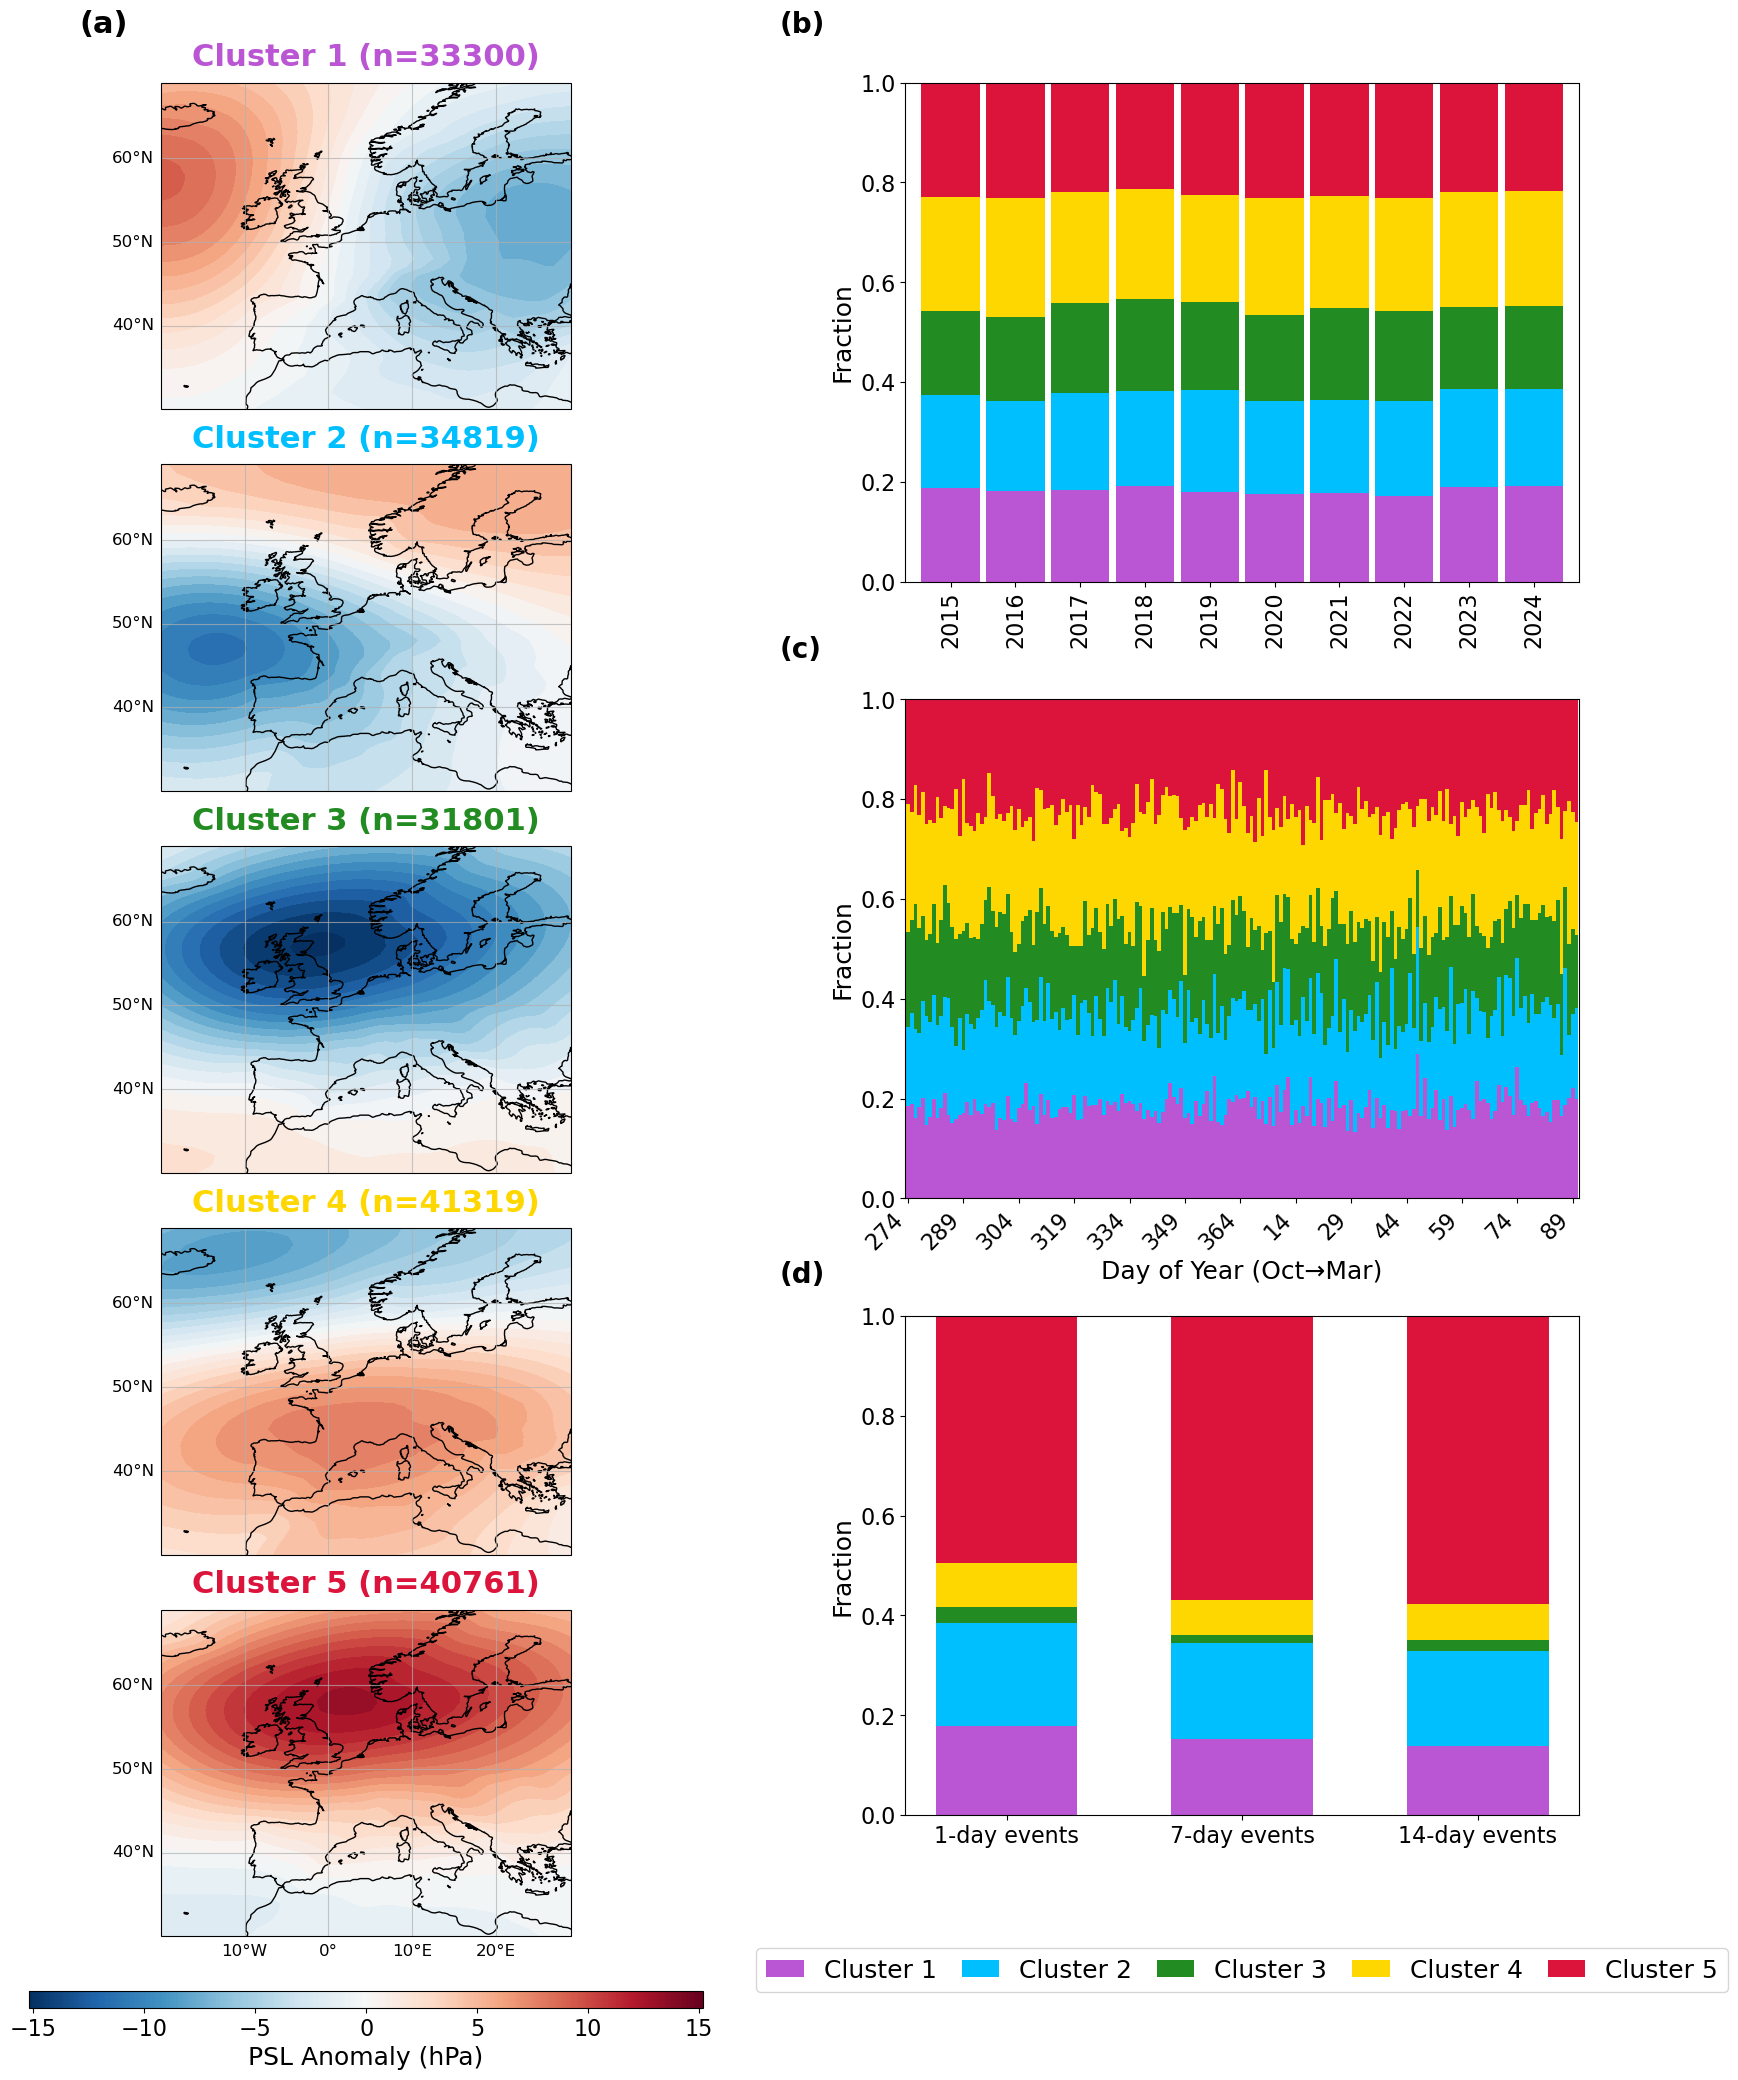

In [37]:
# --- Make all text bigger (global defaults) ---
mpl.rcParams.update({
    'font.size': 16,           # base font size
    'axes.titlesize': 20,      # axes titles
    'axes.labelsize': 18,      # x/y labels
    'xtick.labelsize': 16,     # x tick labels
    'ytick.labelsize': 16,     # y tick labels
    'legend.fontsize': 18,     # legend text
    'figure.titlesize': 22,    # figure title (if used)
})

# make the entire figure a bit smaller than before
fig = plt.figure(figsize=(20, 25))
outer = GridSpec(1, 2, width_ratios=[1, 1], wspace=0.3)

# ─── Left column: 5 maps + shared colorbar ──────────────────────────────
left_gs = outer[0].subgridspec(6, 1, height_ratios=[1,1,1,1,1,0.05], hspace=0.2)
lons = ((ts_datasets['lon'].values + 180) % 360) - 180
lats = ts_datasets['lat'].values
vmin = np.nanmin(centroids_reshaped / 100.0)
vmax = -vmin

for i in range(5):
    ax = fig.add_subplot(left_gs[i, 0], projection=ccrs.PlateCarree())
    cf = ax.contourf(
        lons, lats, centroids_reshaped[i] / 100.0,
        levels=20, vmin=vmin, vmax=vmax,
        cmap="RdBu_r", transform=ccrs.PlateCarree()
    )
    ax.coastlines()
    setup_gridlines(ax, deg=10, alpha=0.7, ll=True, bl=(i==4), label_size=12)  # increased tick label size for maps
    ax.set_title(
        f"Cluster {i+1} (n={cluster_counts[i]})",
        color=cluster_colors[i],
        fontsize=22,              # increased
        fontweight='bold',
        pad=12
    )
    ax.tick_params(labelsize=16)  # increase tick labels

# colorbar in the tiny bottom row
cax = fig.add_subplot(left_gs[5, 0])
sm = ScalarMappable(norm=plt.Normalize(vmin, vmax), cmap=cf.cmap)
sm.set_array([])
cbar = plt.colorbar(sm, cax=cax, orientation='horizontal')
cbar.set_label('PSL Anomaly (hPa)', fontsize=18)  # increased
cbar.ax.tick_params(labelsize=16)

fig.text(0.15, 0.9, "(a)", fontsize=22, fontweight="bold")  # increased

# ─── Right column: 3 vertical panels (b),(c),(d) ─────────────────────────
right_gs = outer[1].subgridspec(4, 1, height_ratios=[1,1,1,0.15], hspace=0.3)

# (b) Yearly fractions
axb = fig.add_subplot(right_gs[0, 0])
yearly_frac.T.plot(
    kind="bar", stacked=True, ax=axb, width=0.9,
    color=[cluster_palette[c] for c in df_year.columns],
    legend=False
)
axb.set_ylim(0, 1)
axb.set_xlabel("", fontsize=18)       # ensure label fontsize
axb.set_ylabel("Fraction", fontsize=18)  # increased
axb.tick_params(labelsize=16)         # increase tick labels
fig.text(0.5, 0.9, "(b)", fontsize=20, fontweight="bold")  # increased

# (c) Day‐of‐Year Oct→Mar
axc = fig.add_subplot(right_gs[1, 0])
order = np.concatenate([days[(days>=274)&(days<=365)], days[(days>=1)&(days<=90)]])
doy_frac[order].T.plot(
    kind="bar", stacked=True, ax=axc, width=1,
    color=[cluster_palette[c] for c in doy_frac.index],
    legend=False
)
axc.set_ylim(0, 1)
axc.set_xlabel("Day of Year (Oct→Mar)", fontsize=18)  # increased
axc.set_xticks(np.arange(0, len(order), 15))
axc.set_xticklabels(order[::15], rotation=45, ha="right", fontsize=14)
axc.set_ylabel("Fraction", fontsize=18)  # increased
axc.tick_params(labelsize=16)
fig.text(0.5, 0.65, "(c)", fontsize=20, fontweight="bold")  # increased

# (d) Relative cluster distribution for daily, 7-day, 14-day events
axd = fig.add_subplot(right_gs[2, 0])
bottom = np.zeros(len(dfs))
for c in all_clusters:
    heights = [data[k].get(c, 0) for k in dfs]
    axd.bar(x, heights, 0.6, bottom=bottom, label=f"Cluster {c+1}", color=cluster_palette[c])
    bottom += heights
axd.set_ylim(0, 1)
axd.set_xticks(x)
axd.set_xticklabels(dfs.keys(), fontsize=16)  # increase category labels
axd.set_ylabel("Fraction", fontsize=18)        # increased
axd.tick_params(labelsize=16)
fig.text(0.5, 0.4, "(d)", fontsize=20, fontweight="bold")  # increased

# ─── Dedicated legend row ───────────────────────────────────────────────
caxr = fig.add_subplot(right_gs[3, 0])
caxr.axis('off')

handles = [
    Patch(facecolor=cluster_palette[c], label=f"Cluster {c+1}")
    for c in all_clusters
]

caxr.legend(
    handles=handles,
    loc='center',
    ncol=len(all_clusters),
    fontsize=18,          # bigger legend text
    frameon=True,
    handlelength=1.5,
    columnspacing=1.0
)
# Save the figure
# fig.savefig('/home/onennecke/Code/Figures/cluster_analysis_combined_v2.png', dpi=300, bbox_inches='tight')
plt.show()
